# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [40]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  2569k      0 --:--:--  0:05:50 --:--:-- 8074k


In [49]:
!rm SUSY.csv

rm: SUSY.csv: No such file or directory


In [50]:
!gunzip SUSY.csv.gz

In [51]:
ls -lh

total 4686288
-rw-r--r--  1 carlosg  staff    19K Apr 17 13:01 Lab.7.ipynb
-rw-r--r--@ 1 carlosg  staff   8.0M Apr  6 11:08 Lab.7.pdf
-rw-r--r--  1 carlosg  staff   2.2G Apr 17 12:57 SUSY.csv


The data is provided as a comma separated file.

In [10]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [11]:
!ls -lh

total 5158736
-rw-r--r--  1 carlosg  staff   2.7M Apr 17 17:07 Lab.7.ipynb
-rw-r--r--@ 1 carlosg  staff   8.0M Apr  6 11:08 Lab.7.pdf
-rw-r--r--  1 carlosg  staff   228M Apr 17 13:02 SUSY-small.csv
-rw-r--r--  1 carlosg  staff   2.2G Apr 17 12:57 SUSY.csv


We see that we have 5 million datapoints.

In [13]:
!wc -l SUSY.csv

 5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [17]:
!head -500000 SUSY.csv > SUSY-small.csv

In [18]:
ls -lh

total 5183528
-rw-r--r--  1 carlosg  staff   2.7M Apr 17 17:07 Lab.7.ipynb
-rw-r--r--@ 1 carlosg  staff   8.0M Apr  6 11:08 Lab.7.pdf
-rw-r--r--  1 carlosg  staff   228M Apr 17 17:09 SUSY-small.csv
-rw-r--r--  1 carlosg  staff   2.2G Apr 17 12:57 SUSY.csv


In [19]:
! wc -l SUSY-small.csv

  500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [20]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [21]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [22]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [23]:
FeatureNames

['S_R',
 'dPhi_r_b',
 'R',
 'M_R',
 'MT2',
 'MET_rel',
 'axial_MET',
 'M_Delta_R',
 'M_TR_2',
 'cos_theta_r1']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [29]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [27]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [31]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


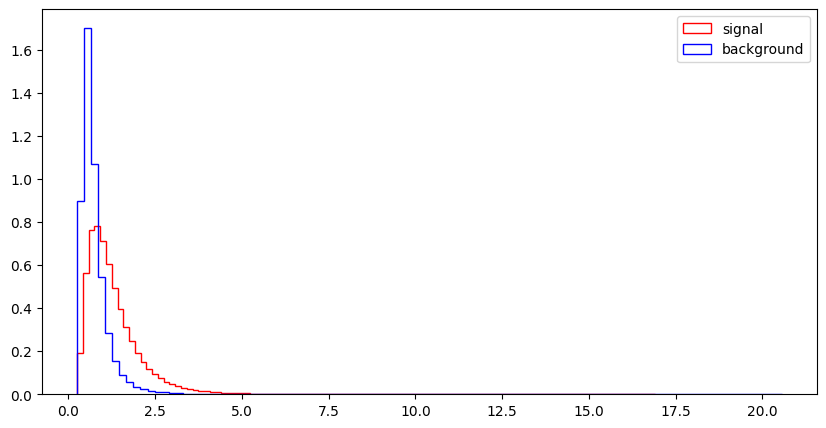

l_1_eta


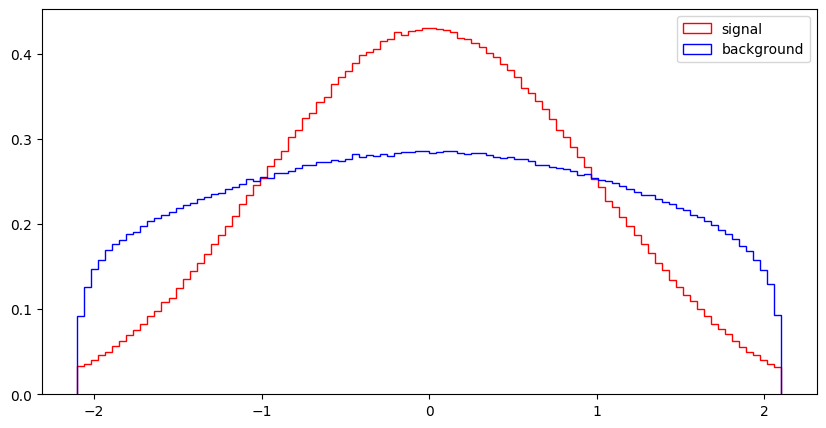

l_1_phi


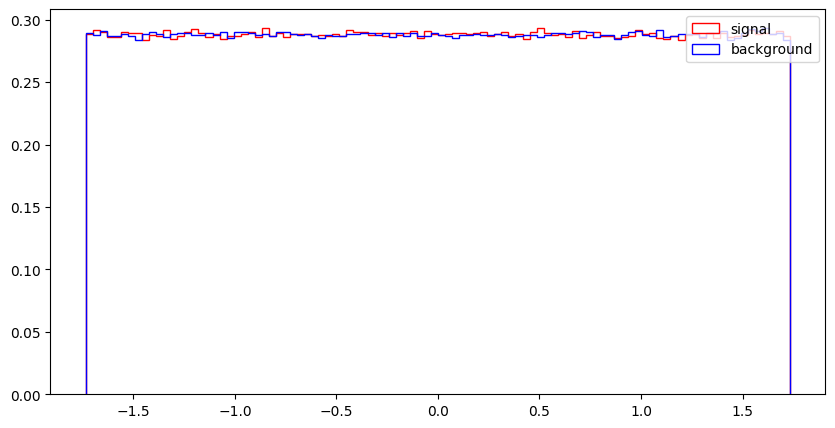

l_2_pT


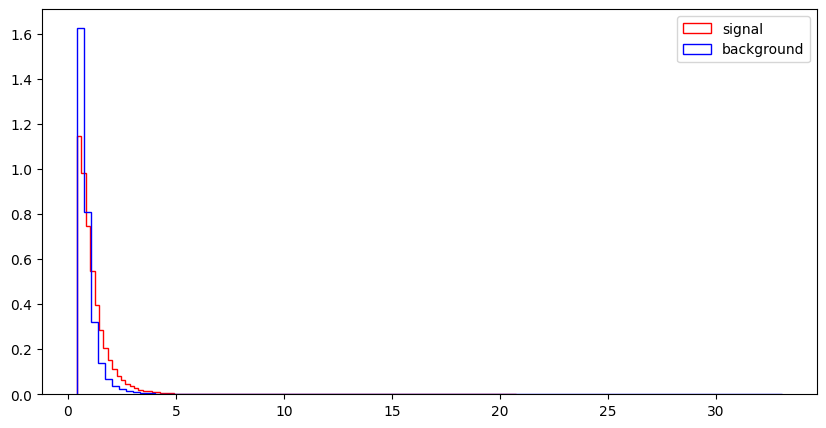

l_2_eta


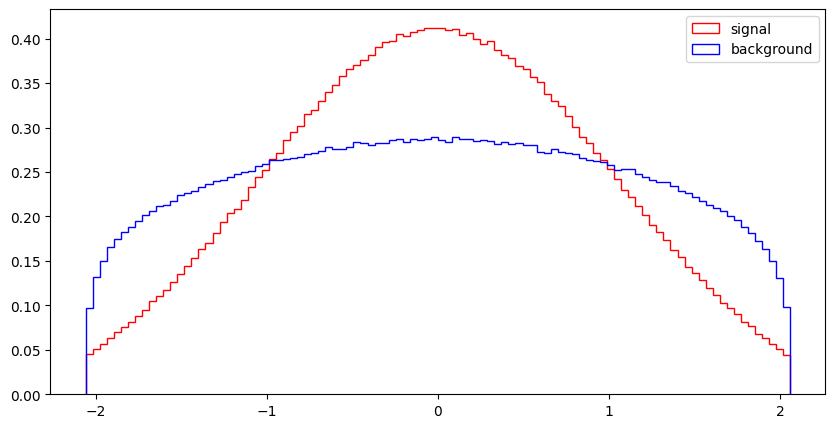

l_2_phi


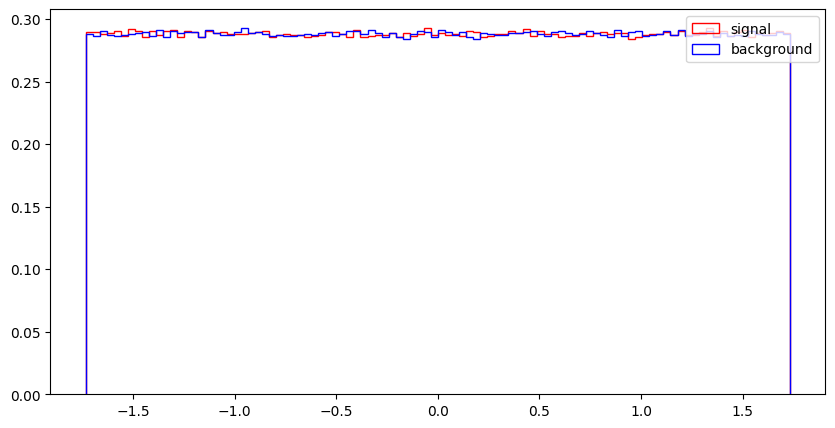

MET


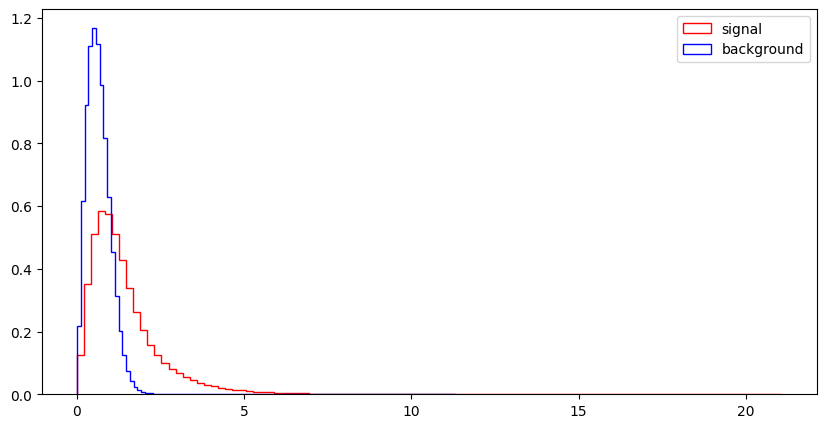

MET_phi


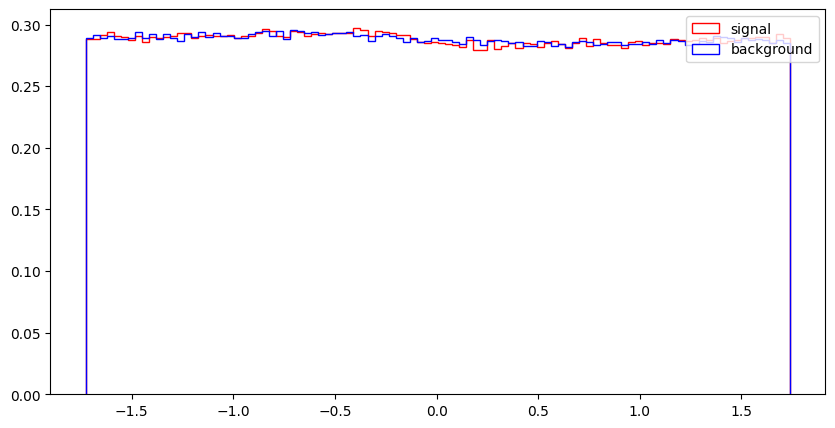

MET_rel


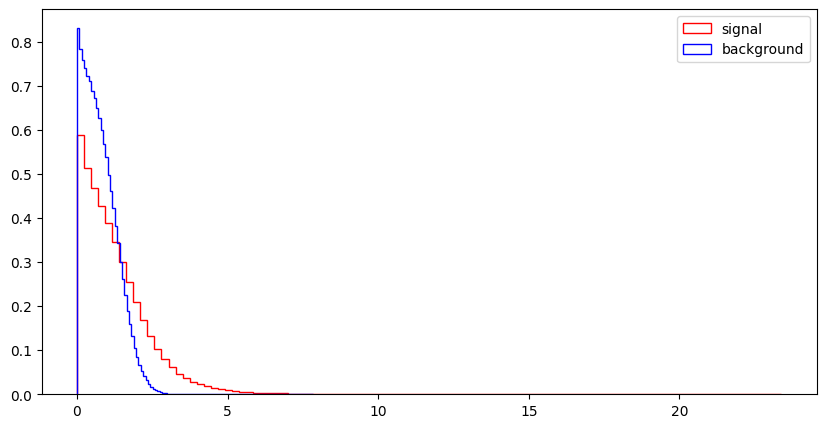

axial_MET


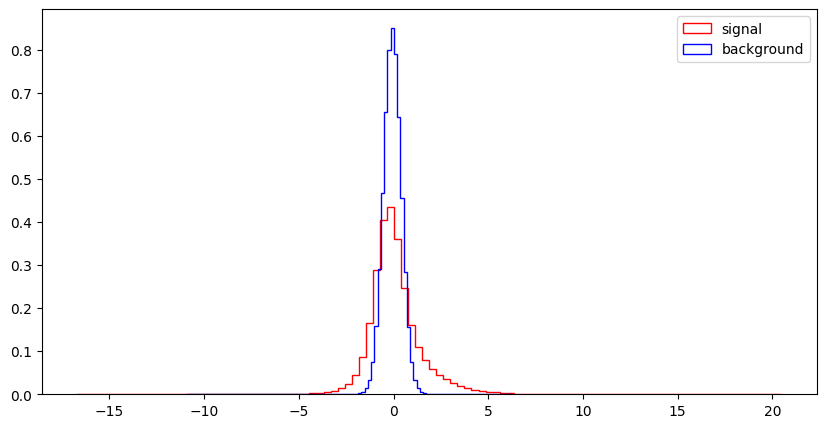

M_R


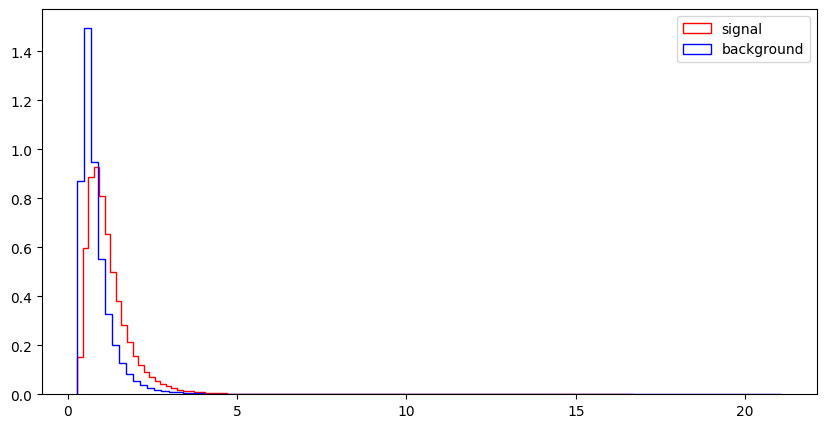

M_TR_2


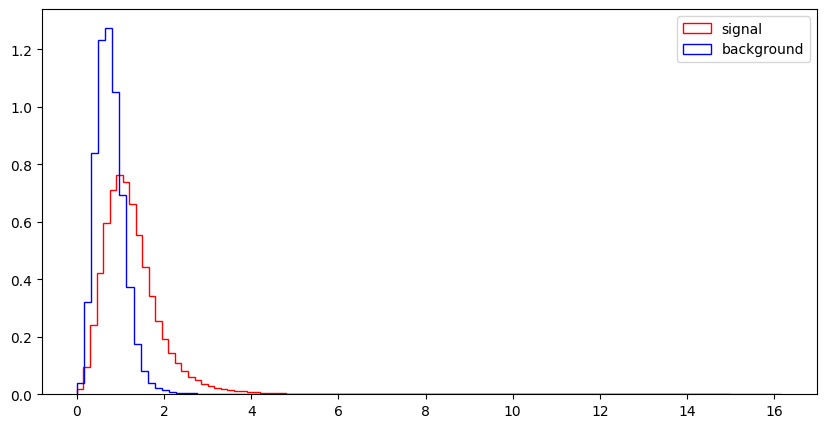

R


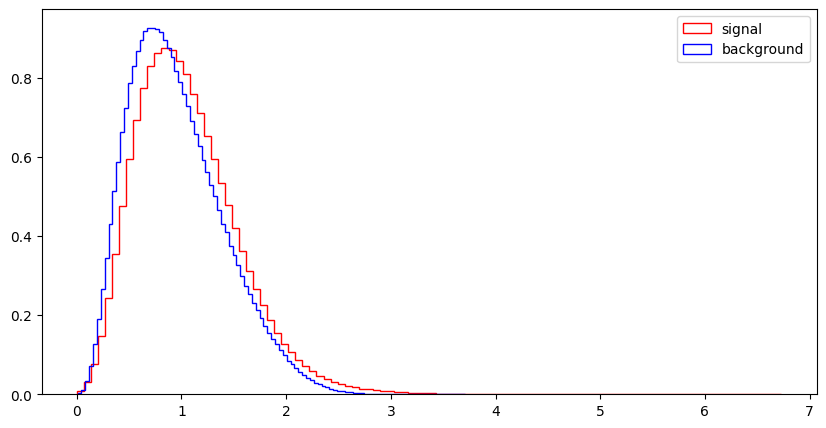

MT2


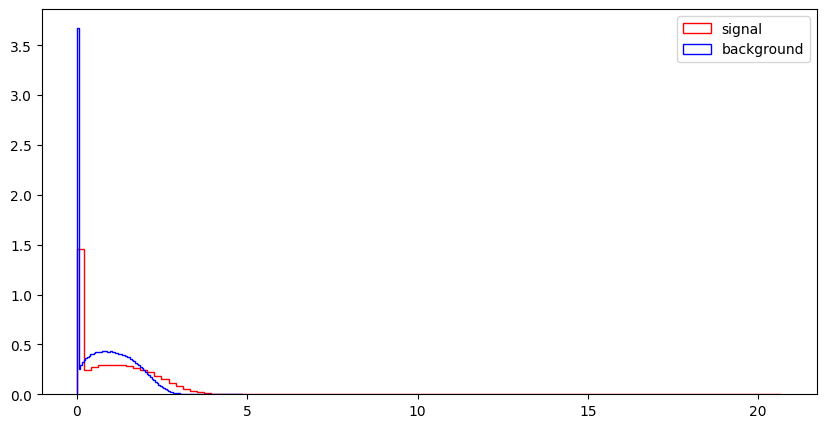

S_R


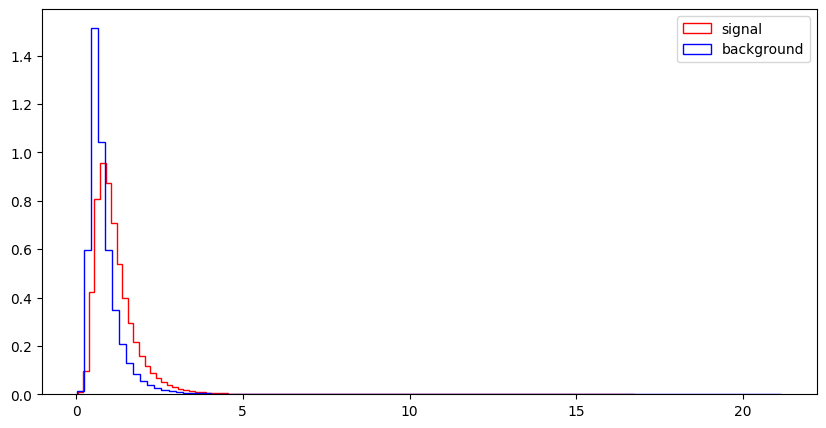

M_Delta_R


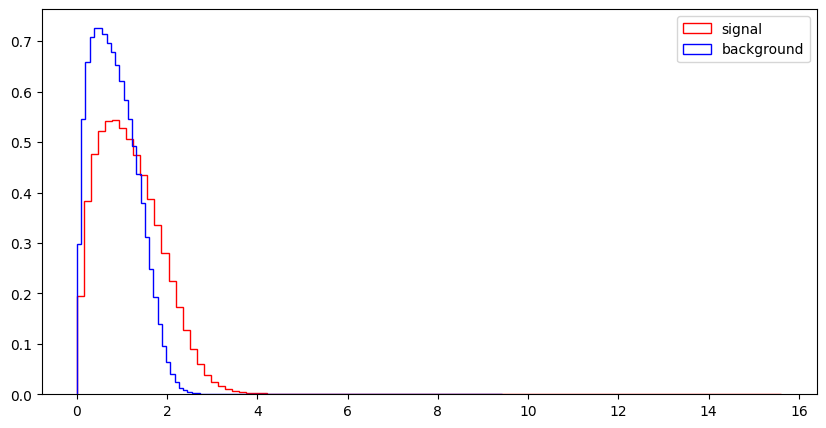

dPhi_r_b


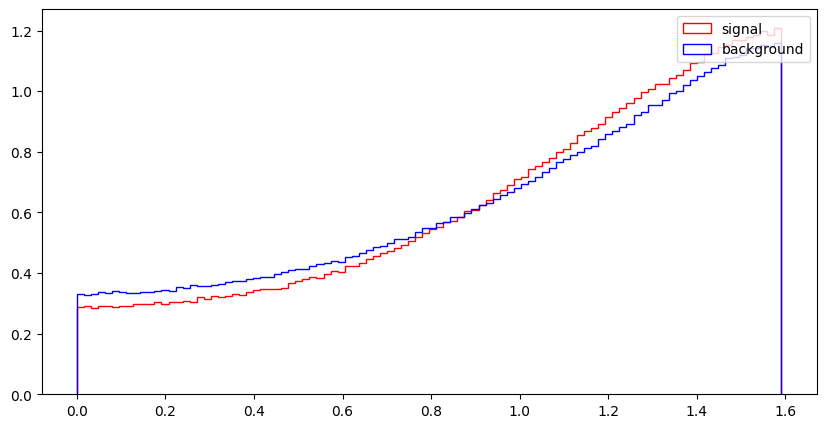

cos_theta_r1


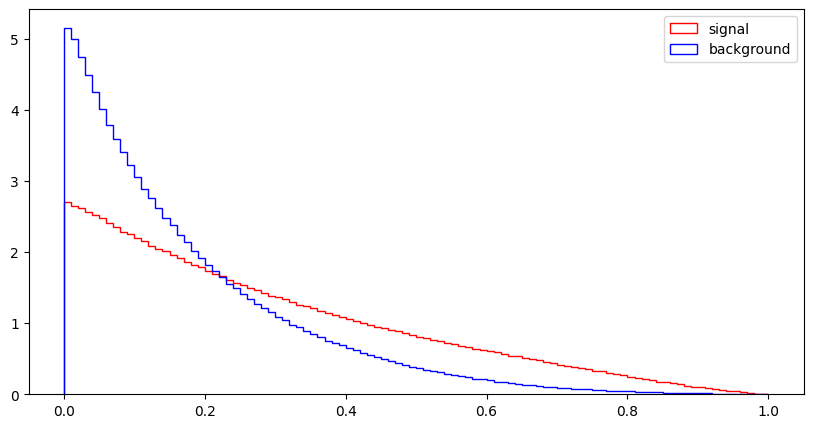

In [44]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

Figure 5: Low-level (Raw) Features


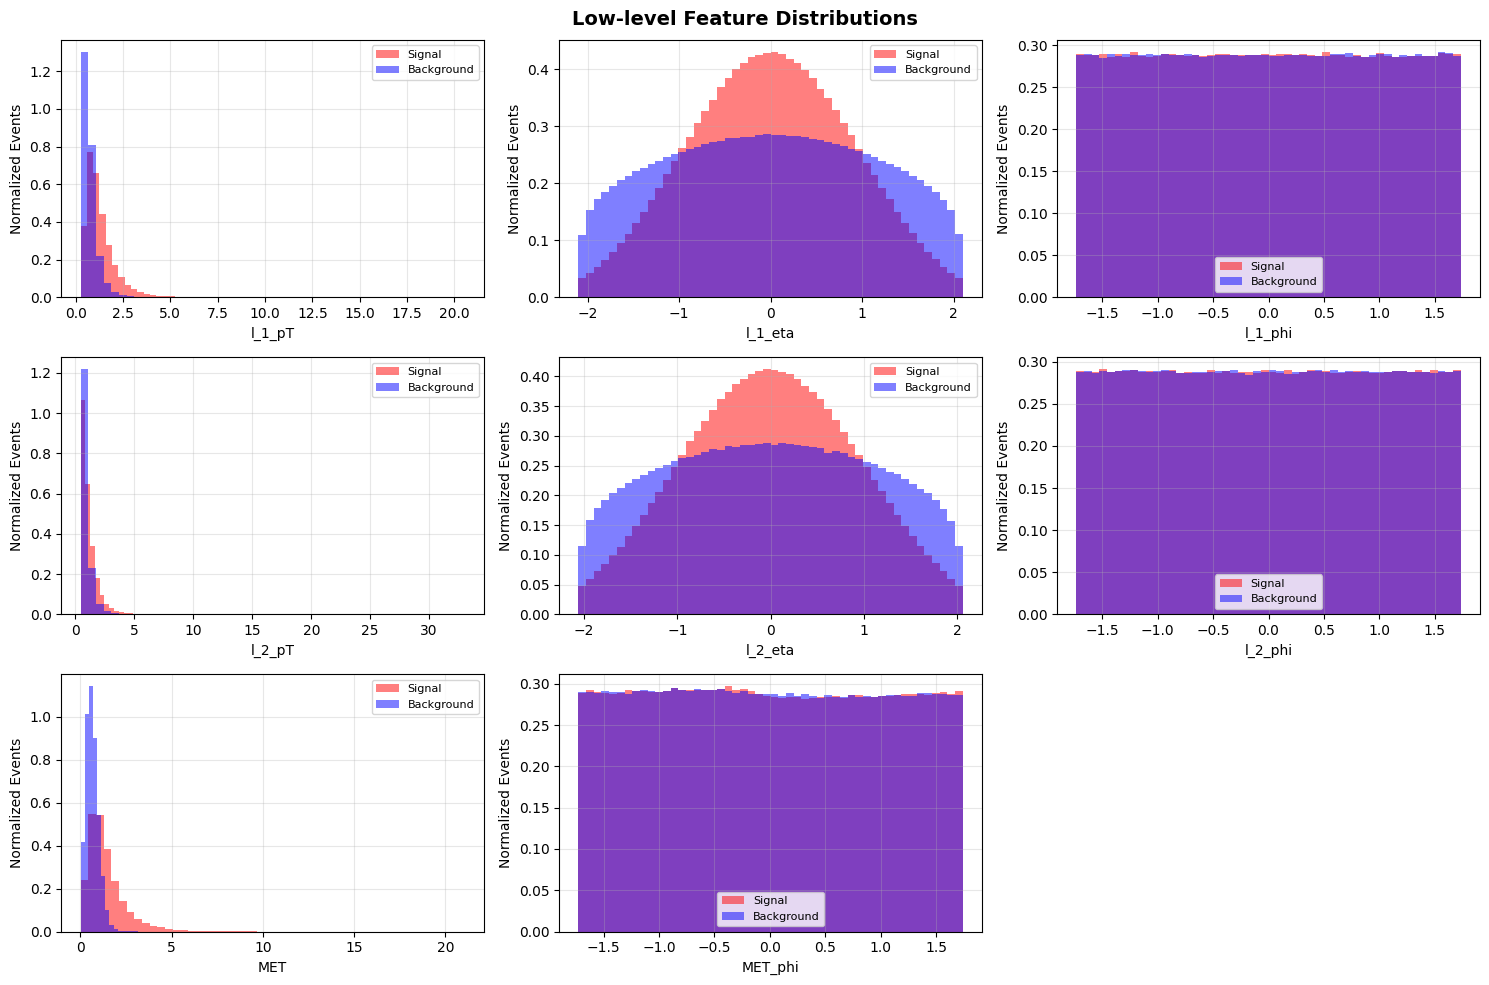


Figure 6: High-level (Engineered) Features


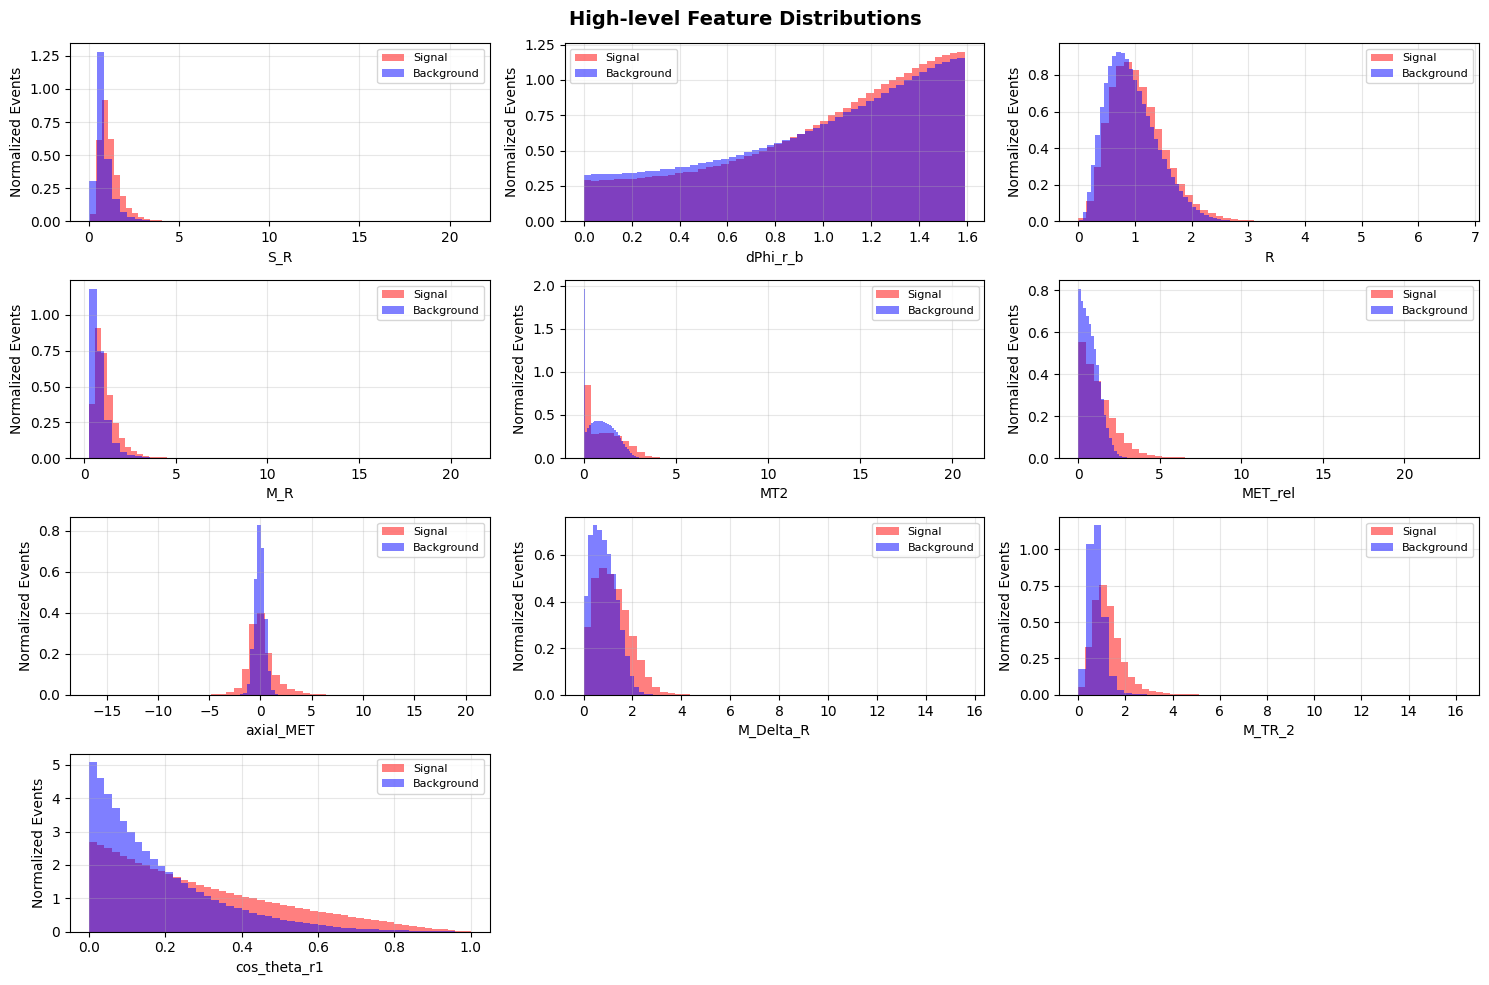

In [43]:
def plot_distributions(variables, df_sig, df_bkg, title, figsize=(15, 10)):
    n_vars = len(variables)
    n_cols = 3
    n_rows = (n_vars + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    for idx, var in enumerate(variables):
        ax = axes[idx]
        
        ax.hist(df_sig[var], bins=50, alpha=0.5, color='red', 
                label='Signal', density=True, histtype='stepfilled')
        ax.hist(df_bkg[var], bins=50, alpha=0.5, color='blue', 
                label='Background', density=True, histtype='stepfilled')
        
        ax.set_xlabel(var, fontsize=10)
        ax.set_ylabel('Normalized Events', fontsize=10)
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    for idx in range(n_vars, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Figure 5: Low-level (Raw) Features")
plot_distributions(RawNames, df_sig, df_bkg, 
                   "Low-level Feature Distributions")

print("\nFigure 6: High-level (Engineered) Features")
plot_distributions(FeatureNames, df_sig, df_bkg, 
                   "High-level Feature Distributions")

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

Pair Plot for Raw Features (Signal)


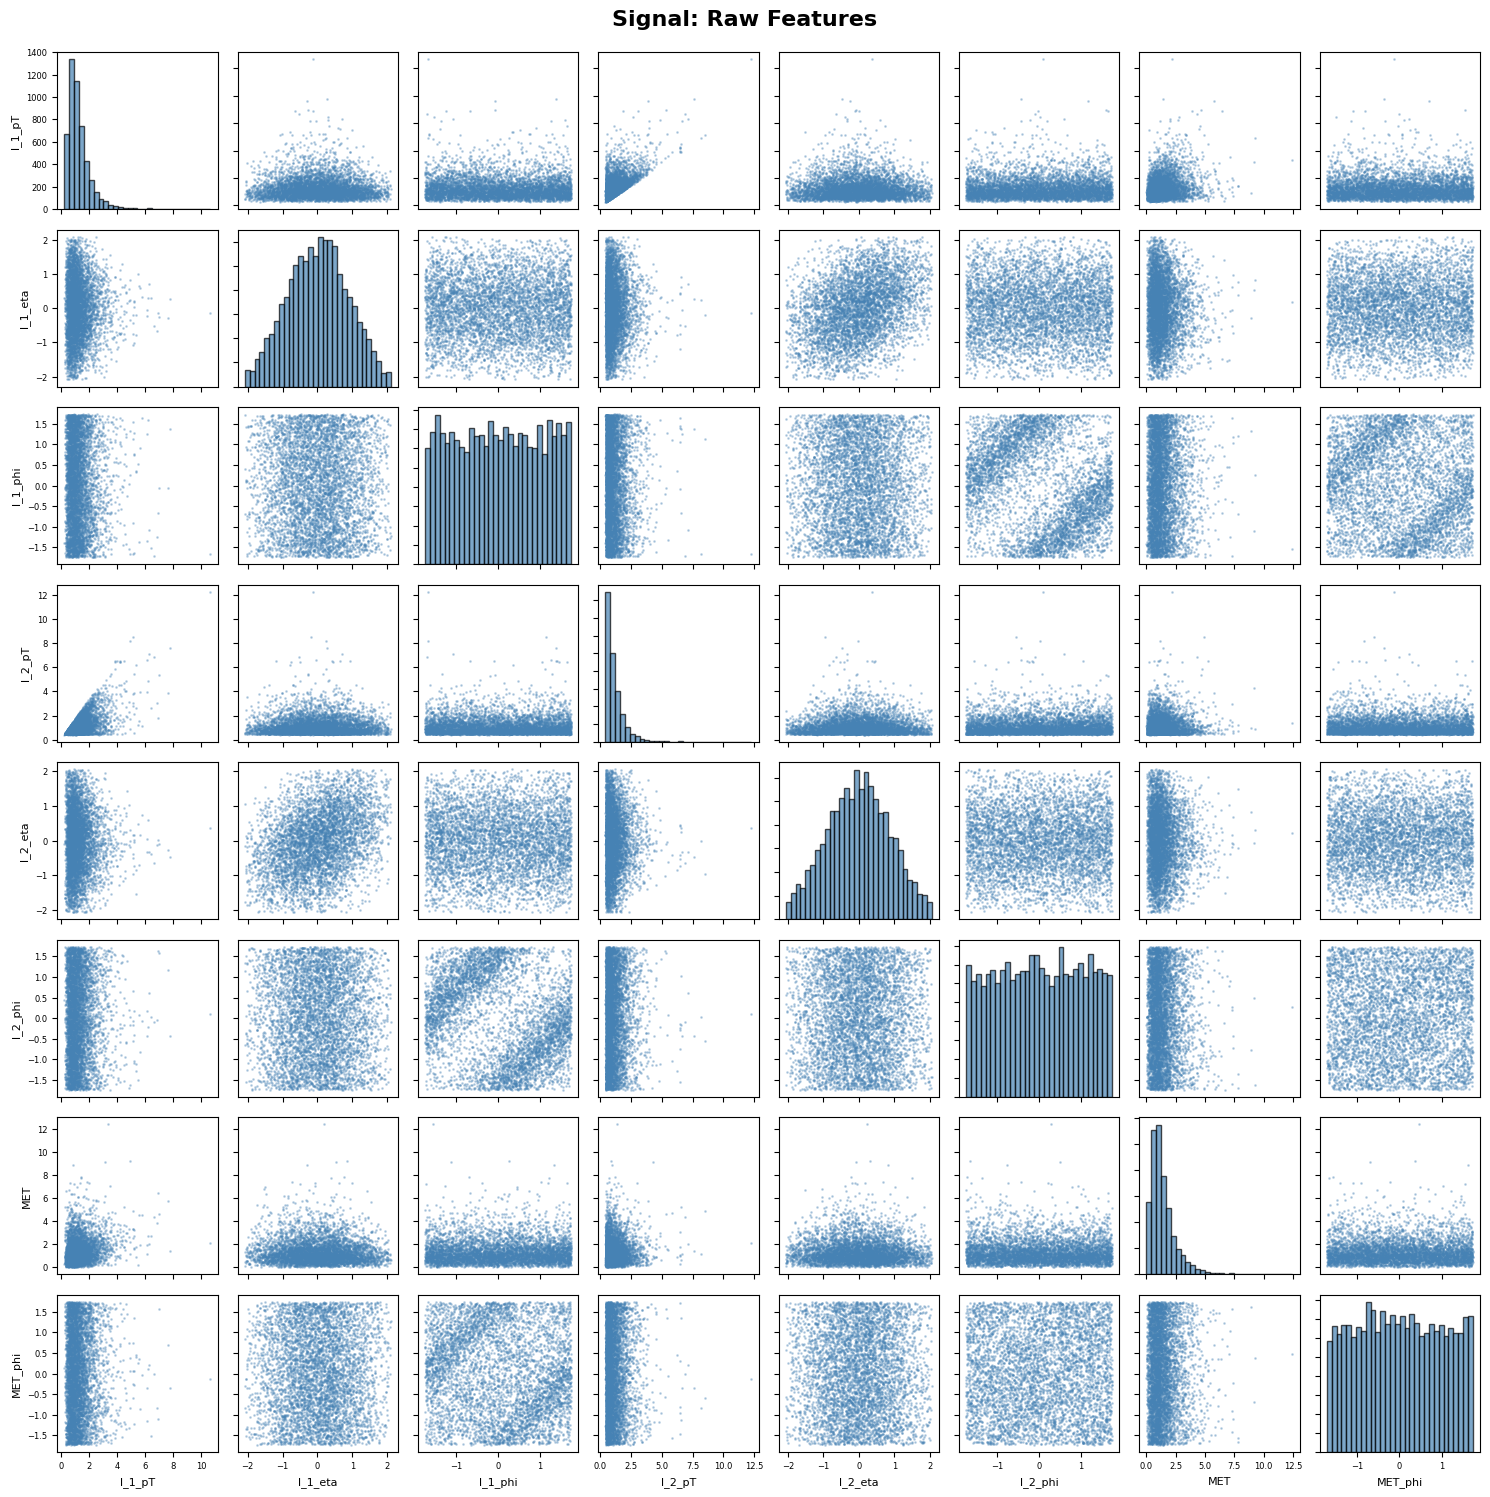


Pair Plot for Engineered Features (Signal)


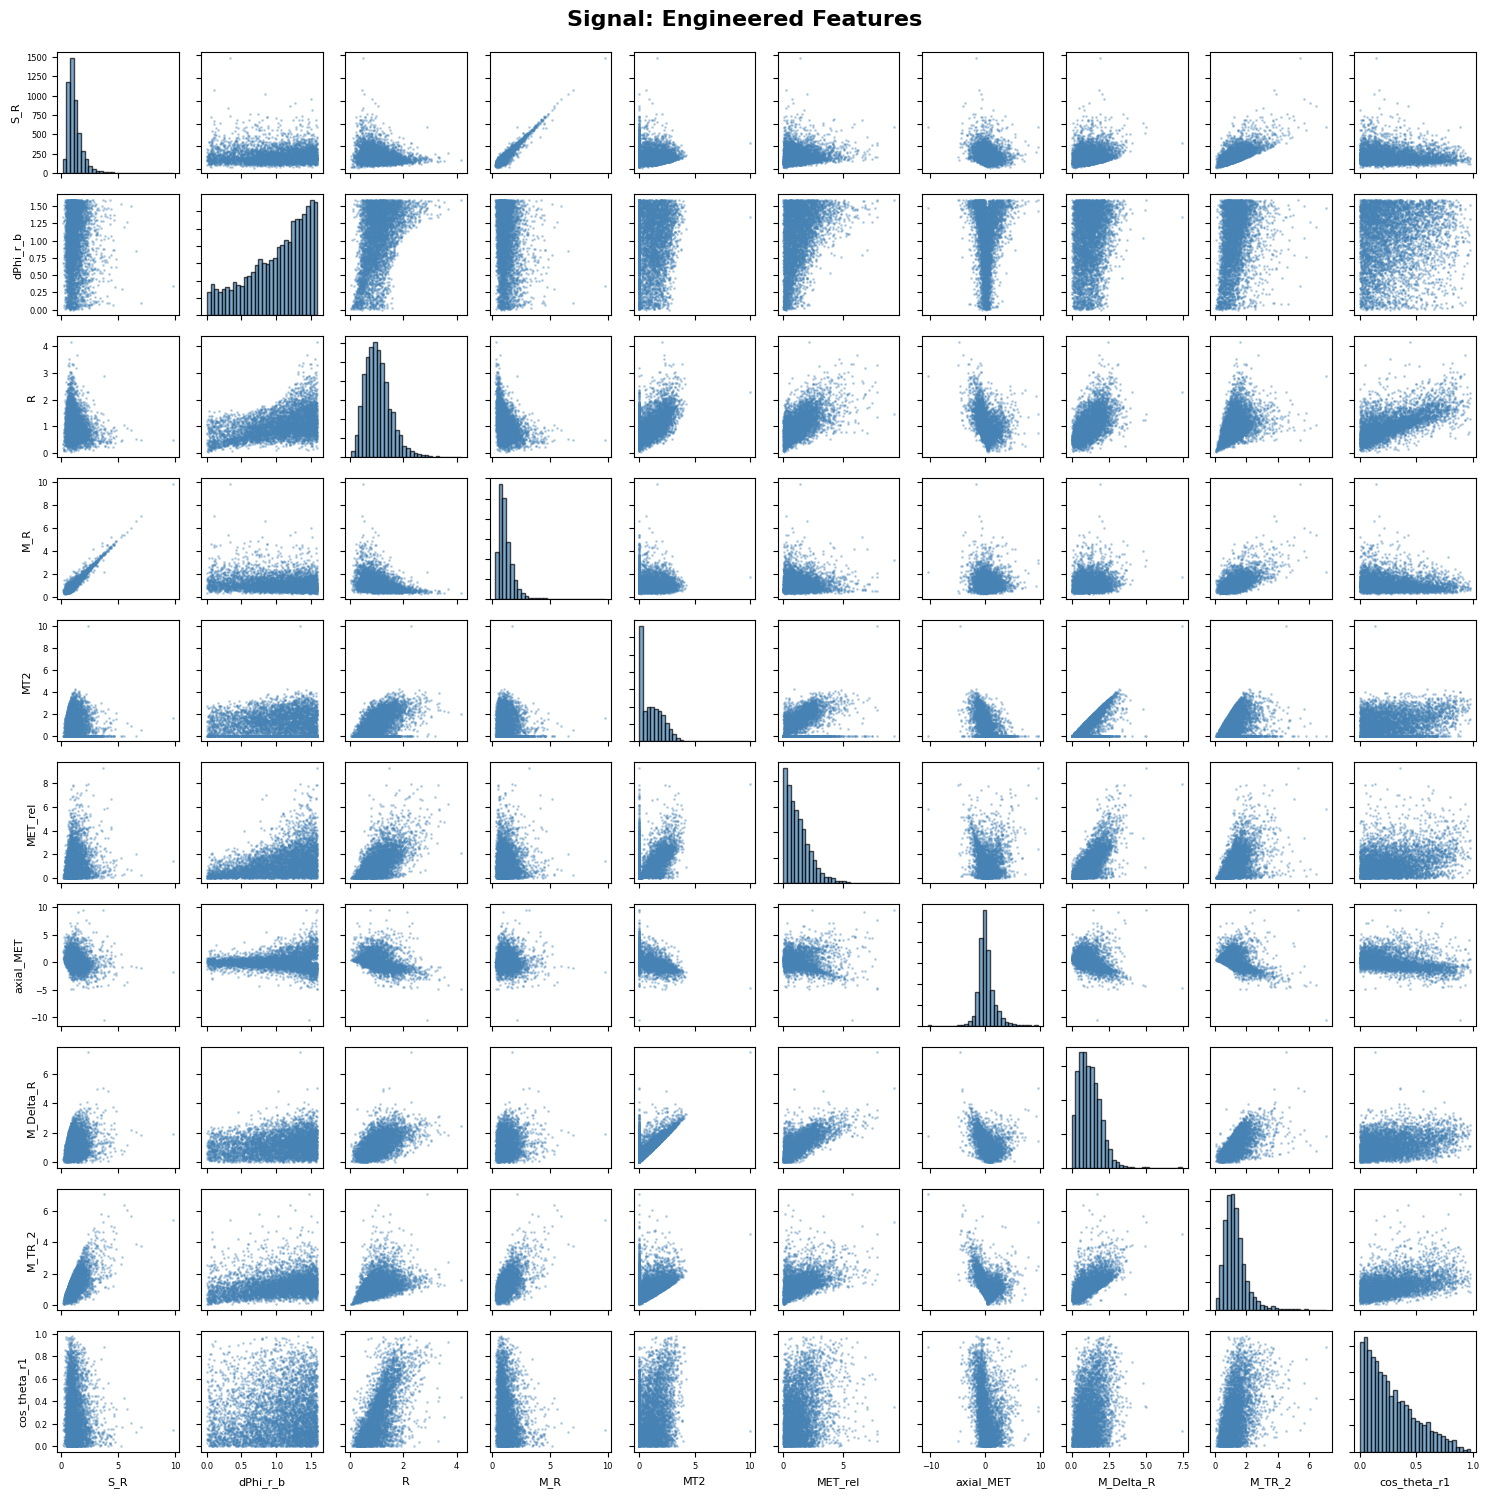

In [42]:
def create_pair_plot(data, var_names, sample_size=5000, title="Pair Plot"):
    if len(data) > sample_size:
        data_sample = data[var_names].sample(sample_size, random_state=42)
    else:
        data_sample = data[var_names]
    
    n_vars = len(var_names)
    fig, axes = plt.subplots(n_vars, n_vars, figsize=(15, 15))
    
    for i in range(n_vars):
        for j in range(n_vars):
            ax = axes[i, j]
            
            if i == j:
                ax.hist(data_sample[var_names[i]], bins=30, 
                       color='steelblue', alpha=0.7, edgecolor='black')
                ax.set_ylabel('Count' if j == 0 else '')
            else:
                ax.scatter(data_sample[var_names[j]], 
                          data_sample[var_names[i]], 
                          alpha=0.3, s=1, color='steelblue')
            
            if i == n_vars - 1:
                ax.set_xlabel(var_names[j], fontsize=8)
            else:
                ax.set_xticklabels([])
            
            if j == 0:
                ax.set_ylabel(var_names[i], fontsize=8)
            else:
                ax.set_yticklabels([])
            
            ax.tick_params(labelsize=6)
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

print("Pair Plot for Raw Features (Signal)")
create_pair_plot(df_sig, RawNames, title="Signal: Raw Features")

print("\nPair Plot for Engineered Features (Signal)")
create_pair_plot(df_sig, FeatureNames, title="Signal: Engineered Features")

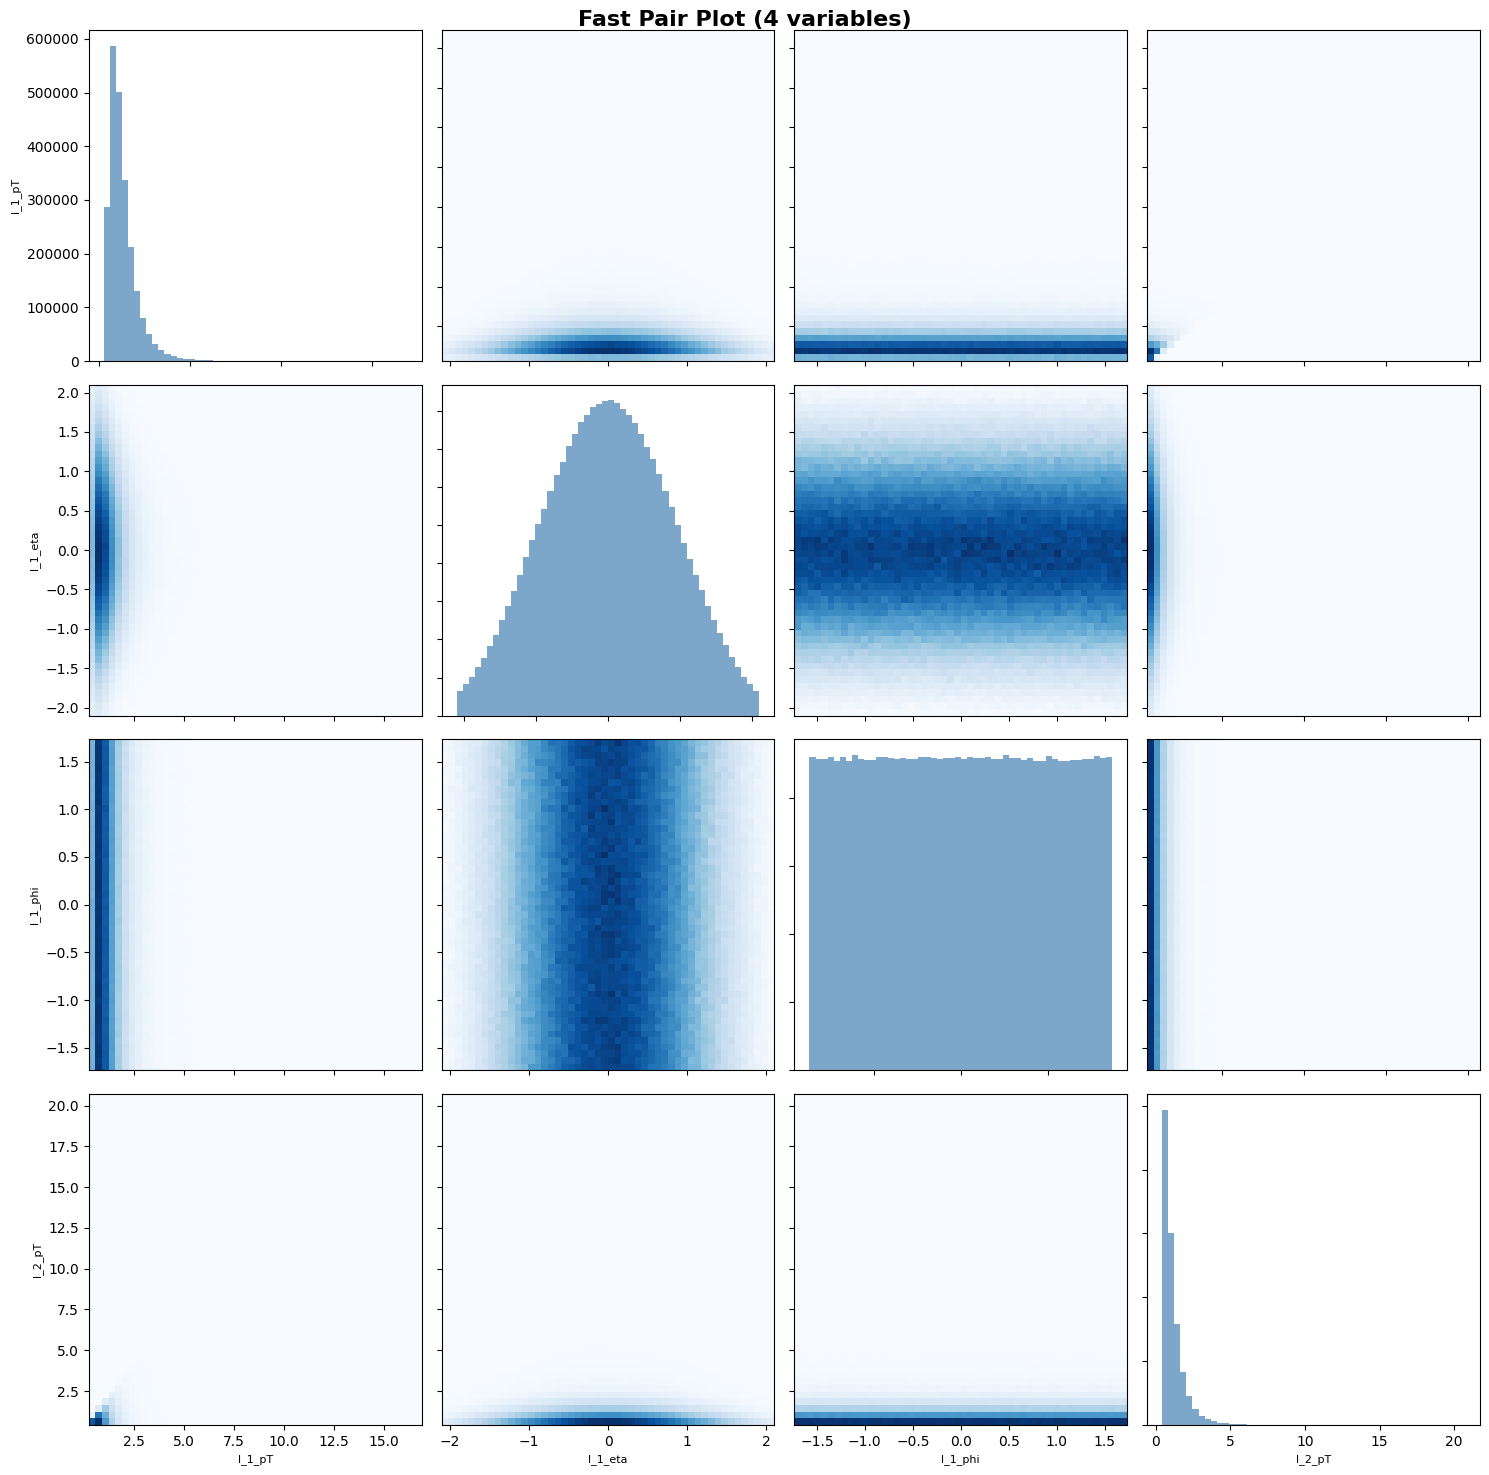

In [40]:
def create_pair_plot_fast(data, var_names, bins=50, title="Pair Plot"):
    n_vars = len(var_names)
    fig, axes = plt.subplots(n_vars, n_vars, figsize=(15, 15))
    
    for i in range(n_vars):
        for j in range(n_vars):
            ax = axes[i, j]
            
            if i == j:
                ax.hist(data[var_names[i]], bins=bins, 
                       color='steelblue', alpha=0.7)
            else:
                ax.hist2d(data[var_names[j]], data[var_names[i]], 
                         bins=bins, cmap='Blues')
            
            if i == n_vars - 1:
                ax.set_xlabel(var_names[j], fontsize=8)
            else:
                ax.set_xticklabels([])
            
            if j == 0:
                ax.set_ylabel(var_names[i], fontsize=8)
            else:
                ax.set_yticklabels([])
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

create_pair_plot_fast(df_sig, RawNames[:4], title="Fast Pair Plot (4 variables)")

In [45]:
def calculate_separation(df_sig, df_bkg, variable):
    mean_sig = df_sig[variable].mean()
    mean_bkg = df_bkg[variable].mean()
    std_sig = df_sig[variable].std()
    std_bkg = df_bkg[variable].std()
    
    combined_std = np.sqrt((std_sig**2 + std_bkg**2) / 2)
    
    separation = abs(mean_sig - mean_bkg) / combined_std
    
    return separation

separations = {}
for var in VarNames[1:]:
    sep = calculate_separation(df_sig, df_bkg, var)
    separations[var] = sep

sorted_sep = sorted(separations.items(), key=lambda x: x[1], reverse=True)

print("Variables ranked by separation power:")
print("="*50)
for var, sep in sorted_sep:
    print(f"{var:15s}: {sep:.4f}")

print("\nTop 3 variables for separation:")
for i, (var, sep) in enumerate(sorted_sep[:3], 1):
    print(f"{i}. {var}: {sep:.4f}")

Variables ranked by separation power:
MET            : 0.9458
M_TR_2         : 0.9129
l_1_pT         : 0.8240
MET_rel        : 0.5762
M_Delta_R      : 0.5616
cos_theta_r1   : 0.5529
M_R            : 0.5509
S_R            : 0.5330
l_2_pT         : 0.3933
R              : 0.2253
MT2            : 0.1580
axial_MET      : 0.1499
dPhi_r_b       : 0.0657
l_1_phi        : 0.0009
l_2_eta        : 0.0008
l_1_eta        : 0.0007
MET_phi        : 0.0002
l_2_phi        : 0.0002

Top 3 variables for separation:
1. MET: 0.9458
2. M_TR_2: 0.9129
3. l_1_pT: 0.8240


### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

Hint: Example code for embedding a `tabulate` table into a notebook:

In [36]:
!pip install tabulate

In [77]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 26.1 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
      Successfully uninstalled pip-25.3
Note: you may need to restart the kernel to use updated packages.


In [46]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [47]:
def compute_correlation_matrices(df, var_names):
    data = df[var_names].values
    
    cov_matrix = np.cov(data, rowvar=False)
    
    corr_matrix = np.corrcoef(data, rowvar=False)
    
    return cov_matrix, corr_matrix

all_obs = VarNames[1:]
cov_all, corr_all = compute_correlation_matrices(df, all_obs)

cov_raw, corr_raw = compute_correlation_matrices(df, RawNames)
cov_feat, corr_feat = compute_correlation_matrices(df, FeatureNames)

print("Covariance and correlation matrices computed")
print(f"All observables: {len(all_obs)} variables")
print(f"Raw features: {len(RawNames)} variables")
print(f"Engineered features: {len(FeatureNames)} variables")

Covariance and correlation matrices computed
All observables: 18 variables
Raw features: 8 variables
Engineered features: 10 variables


In [48]:
def format_matrix_table(matrix, var_names, title, precision=3):
    matrix_rounded = np.round(matrix, precision)
    
    table_data = []
    for i, var in enumerate(var_names):
        row = [var] + list(matrix_rounded[i, :])
        table_data.append(row)
    
    headers = [""] + var_names
    
    print(f"{title}")
    
    html_table = tabulate.tabulate(table_data, headers=headers, 
                                    tablefmt='html', floatfmt=f'.{precision}f')
    display(HTML(html_table))
    
    return html_table

format_matrix_table(corr_all, all_obs, "Correlation Matrix - All Observables", precision=2)

format_matrix_table(corr_raw, RawNames, "Correlation Matrix - Raw Features", precision=2)

format_matrix_table(corr_feat, FeatureNames, "Correlation Matrix - Engineered Features", precision=2)

Correlation Matrix - All Observables


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1.00,-0.00,-0.00,0.68,-0.00,0.00,0.38,-0.00,0.16,-0.02,0.85,0.72,-0.18,-0.02,0.81,0.23,-0.16,0.17
l_1_eta,-0.00,1.00,0.00,-0.00,0.40,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00
l_1_phi,-0.00,0.00,1.00,-0.00,0.00,-0.27,0.00,-0.18,0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
l_2_pT,0.68,-0.00,-0.00,1.00,-0.00,0.00,0.14,-0.00,-0.00,0.08,0.80,0.43,-0.32,-0.12,0.80,0.01,-0.01,-0.22
l_2_eta,-0.00,0.40,0.00,-0.00,1.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00
l_2_phi,0.00,0.00,-0.27,0.00,-0.00,1.00,0.00,-0.03,0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00
MET,0.38,-0.00,0.00,0.14,0.00,0.00,1.00,-0.00,0.71,0.17,0.27,0.72,0.46,0.21,0.31,0.58,0.38,0.43
MET_phi,-0.00,-0.00,-0.18,-0.00,-0.00,-0.03,-0.00,1.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00
MET_rel,0.16,-0.00,0.00,-0.00,0.00,0.00,0.71,-0.00,1.00,-0.14,0.08,0.58,0.60,0.54,0.15,0.75,0.38,0.32
axial_MET,-0.02,-0.00,-0.00,0.08,-0.00,-0.00,0.17,-0.00,-0.14,1.00,0.02,-0.32,-0.39,-0.53,-0.07,-0.37,-0.06,-0.27


Correlation Matrix - Raw Features


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1.00,-0.00,-0.00,0.68,-0.00,0.00,0.38,-0.00
l_1_eta,-0.00,1.00,0.00,-0.00,0.40,0.00,-0.00,-0.00
l_1_phi,-0.00,0.00,1.00,-0.00,0.00,-0.27,0.00,-0.18
l_2_pT,0.68,-0.00,-0.00,1.00,-0.00,0.00,0.14,-0.00
l_2_eta,-0.00,0.40,0.00,-0.00,1.00,-0.00,0.00,-0.00
l_2_phi,0.00,0.00,-0.27,0.00,-0.00,1.00,0.00,-0.03
MET,0.38,-0.00,0.00,0.14,0.00,0.00,1.00,-0.00
MET_phi,-0.00,-0.00,-0.18,-0.00,-0.00,-0.03,-0.00,1.00


Correlation Matrix - Engineered Features


,S_R,dPhi_r_b,R,M_R,MT2,MET_rel,axial_MET,M_Delta_R,M_TR_2,cos_theta_r1
S_R,1.00,-0.01,-0.29,0.98,-0.02,0.15,-0.07,0.25,0.64,-0.08
dPhi_r_b,-0.01,1.00,0.42,-0.11,0.06,0.38,-0.06,0.16,0.23,0.11
R,-0.29,0.42,1.00,-0.38,0.57,0.60,-0.39,0.56,0.38,0.63
M_R,0.98,-0.11,-0.38,1.00,-0.07,0.08,0.02,0.19,0.58,-0.11
MT2,-0.02,0.06,0.57,-0.07,1.00,0.54,-0.53,0.81,0.38,0.26
MET_rel,0.15,0.38,0.60,0.08,0.54,1.00,-0.14,0.75,0.58,0.32
axial_MET,-0.07,-0.06,-0.39,0.02,-0.53,-0.14,1.00,-0.37,-0.32,-0.27
M_Delta_R,0.25,0.16,0.56,0.19,0.81,0.75,-0.37,1.00,0.67,0.32
M_TR_2,0.64,0.23,0.38,0.58,0.38,0.58,-0.32,0.67,1.00,0.45
cos_theta_r1,-0.08,0.11,0.63,-0.11,0.26,0.32,-0.27,0.32,0.45,1.00


,S_R,dPhi_r_b,R,M_R,MT2,MET_rel,axial_MET,M_Delta_R,M_TR_2,cos_theta_r1
S_R,1.00,-0.01,-0.29,0.98,-0.02,0.15,-0.07,0.25,0.64,-0.08
dPhi_r_b,-0.01,1.00,0.42,-0.11,0.06,0.38,-0.06,0.16,0.23,0.11
R,-0.29,0.42,1.00,-0.38,0.57,0.60,-0.39,0.56,0.38,0.63
M_R,0.98,-0.11,-0.38,1.00,-0.07,0.08,0.02,0.19,0.58,-0.11
MT2,-0.02,0.06,0.57,-0.07,1.00,0.54,-0.53,0.81,0.38,0.26
MET_rel,0.15,0.38,0.60,0.08,0.54,1.00,-0.14,0.75,0.58,0.32
axial_MET,-0.07,-0.06,-0.39,0.02,-0.53,-0.14,1.00,-0.37,-0.32,-0.27
M_Delta_R,0.25,0.16,0.56,0.19,0.81,0.75,-0.37,1.00,0.67,0.32
M_TR_2,0.64,0.23,0.38,0.58,0.38,0.58,-0.32,0.67,1.00,0.45
cos_theta_r1,-0.08,0.11,0.63,-0.11,0.26,0.32,-0.27,0.32,0.45,1.00


In [49]:
def correlation_analysis(df, var_names, title_prefix="", show_cov=True, show_corr=True):
    cov_matrix, corr_matrix = compute_correlation_matrices(df, var_names)
    
    if show_cov:
        format_matrix_table(cov_matrix, var_names, 
                           f"{title_prefix} Covariance Matrix", precision=4)
    
    if show_corr:
        format_matrix_table(corr_matrix, var_names, 
                           f"{title_prefix} Correlation Matrix", precision=3)
    
    return cov_matrix, corr_matrix

print("CORRELATION ANALYSIS")

cov_raw, corr_raw = correlation_analysis(df, RawNames, title_prefix="Raw Features -")

cov_feat, corr_feat = correlation_analysis(df, FeatureNames, title_prefix="Engineered Features -")

CORRELATION ANALYSIS
Raw Features - Covariance Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,0.4724,-0.0003,-0.0002,0.3079,-0.0003,0.0002,0.2310,-0.0007
l_1_eta,-0.0003,1.0062,0.0003,-0.0004,0.4059,0.0003,-0.0006,-0.0005
l_1_phi,-0.0002,0.0003,1.0033,-0.0001,0.0006,-0.2681,0.0012,-0.1842
l_2_pT,0.3079,-0.0004,-0.0001,0.4280,-0.0005,0.0001,0.0797,-0.0014
l_2_eta,-0.0003,0.4059,0.0006,-0.0005,1.0057,-0.0001,0.0001,-0.0001
l_2_phi,0.0002,0.0003,-0.2681,0.0001,-0.0001,1.0033,0.0000,-0.0345
MET,0.2310,-0.0006,0.0012,0.0797,0.0001,0.0000,0.7619,-0.0016
MET_phi,-0.0007,-0.0005,-0.1842,-0.0014,-0.0001,-0.0345,-0.0016,1.0033


Raw Features - Correlation Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1.000,-0.000,-0.000,0.685,-0.000,0.000,0.385,-0.001
l_1_eta,-0.000,1.000,0.000,-0.001,0.403,0.000,-0.001,-0.001
l_1_phi,-0.000,0.000,1.000,-0.000,0.001,-0.267,0.001,-0.184
l_2_pT,0.685,-0.001,-0.000,1.000,-0.001,0.000,0.140,-0.002
l_2_eta,-0.000,0.403,0.001,-0.001,1.000,-0.000,0.000,-0.000
l_2_phi,0.000,0.000,-0.267,0.000,-0.000,1.000,0.000,-0.034
MET,0.385,-0.001,0.001,0.140,0.000,0.000,1.000,-0.002
MET_phi,-0.001,-0.001,-0.184,-0.002,-0.000,-0.034,-0.002,1.000


Engineered Features - Covariance Matrix


,S_R,dPhi_r_b,R,M_R,MT2,MET_rel,axial_MET,M_Delta_R,M_TR_2,cos_theta_r1
S_R,0.3853,-0.0036,-0.0834,0.3831,-0.0112,0.0824,-0.0434,0.0961,0.2304,-0.0102
dPhi_r_b,-0.0036,0.1902,0.0871,-0.0291,0.0212,0.1466,-0.0262,0.0424,0.0581,0.0091
R,-0.0834,0.0871,0.2217,-0.1129,0.2322,0.2495,-0.1816,0.1656,0.1045,0.0582
M_R,0.3831,-0.0291,-0.1129,0.3954,-0.0366,0.0437,0.0151,0.0743,0.2122,-0.0142
MT2,-0.0112,0.0212,0.2322,-0.0366,0.7383,0.4100,-0.4603,0.4333,0.1895,0.0445
MET_rel,0.0824,0.1466,0.2495,0.0437,0.4100,0.7924,-0.1253,0.4157,0.3033,0.0556
axial_MET,-0.0434,-0.0262,-0.1816,0.0151,-0.4603,-0.1253,1.0032,-0.2341,-0.1887,-0.0541
M_Delta_R,0.0961,0.0424,0.1656,0.0743,0.4333,0.4157,-0.2341,0.3891,0.2425,0.0392
M_TR_2,0.2304,0.0581,0.1045,0.2122,0.1895,0.3033,-0.1887,0.2425,0.3412,0.0519
cos_theta_r1,-0.0102,0.0091,0.0582,-0.0142,0.0445,0.0556,-0.0541,0.0392,0.0519,0.0388


Engineered Features - Correlation Matrix


,S_R,dPhi_r_b,R,M_R,MT2,MET_rel,axial_MET,M_Delta_R,M_TR_2,cos_theta_r1
S_R,1.000,-0.013,-0.285,0.981,-0.021,0.149,-0.070,0.248,0.636,-0.084
dPhi_r_b,-0.013,1.000,0.424,-0.106,0.056,0.378,-0.060,0.156,0.228,0.106
R,-0.285,0.424,1.000,-0.381,0.574,0.595,-0.385,0.564,0.380,0.627
M_R,0.981,-0.106,-0.381,1.000,-0.068,0.078,0.024,0.189,0.578,-0.115
MT2,-0.021,0.056,0.574,-0.068,1.000,0.536,-0.535,0.808,0.378,0.263
MET_rel,0.149,0.378,0.595,0.078,0.536,1.000,-0.141,0.749,0.583,0.317
axial_MET,-0.070,-0.060,-0.385,0.024,-0.535,-0.141,1.000,-0.375,-0.323,-0.274
M_Delta_R,0.248,0.156,0.564,0.189,0.808,0.749,-0.375,1.000,0.666,0.319
M_TR_2,0.636,0.228,0.380,0.578,0.378,0.583,-0.323,0.666,1.000,0.451
cos_theta_r1,-0.084,0.106,0.627,-0.115,0.263,0.317,-0.274,0.319,0.451,1.000


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [50]:
def determine_selection_type(df_sig, df_bkg, variable):
    mean_sig = df_sig[variable].mean()
    mean_bkg = df_bkg[variable].mean()
    
    if mean_sig > mean_bkg:
        return 1, "x > x_c (signal at high values)"
    else:
        return 2, "x < x_c (signal at low values)"

selection_criteria = {}
print("Optimal Selection Criteria:")
print("="*70)
for var in VarNames[1:]:
    sel_type, description = determine_selection_type(df_sig, df_bkg, var)
    selection_criteria[var] = sel_type
    print(f"{var:15s}: Type {sel_type} - {description}")

Optimal Selection Criteria:
l_1_pT         : Type 1 - x > x_c (signal at high values)
l_1_eta        : Type 2 - x < x_c (signal at low values)
l_1_phi        : Type 2 - x < x_c (signal at low values)
l_2_pT         : Type 1 - x > x_c (signal at high values)
l_2_eta        : Type 1 - x > x_c (signal at high values)
l_2_phi        : Type 2 - x < x_c (signal at low values)
MET            : Type 1 - x > x_c (signal at high values)
MET_phi        : Type 1 - x > x_c (signal at high values)
MET_rel        : Type 1 - x > x_c (signal at high values)
axial_MET      : Type 1 - x > x_c (signal at high values)
M_R            : Type 1 - x > x_c (signal at high values)
M_TR_2         : Type 1 - x > x_c (signal at high values)
R              : Type 1 - x > x_c (signal at high values)
MT2            : Type 1 - x > x_c (signal at high values)
S_R            : Type 1 - x > x_c (signal at high values)
M_Delta_R      : Type 1 - x > x_c (signal at high values)
dPhi_r_b       : Type 1 - x > x_c (signal at hi

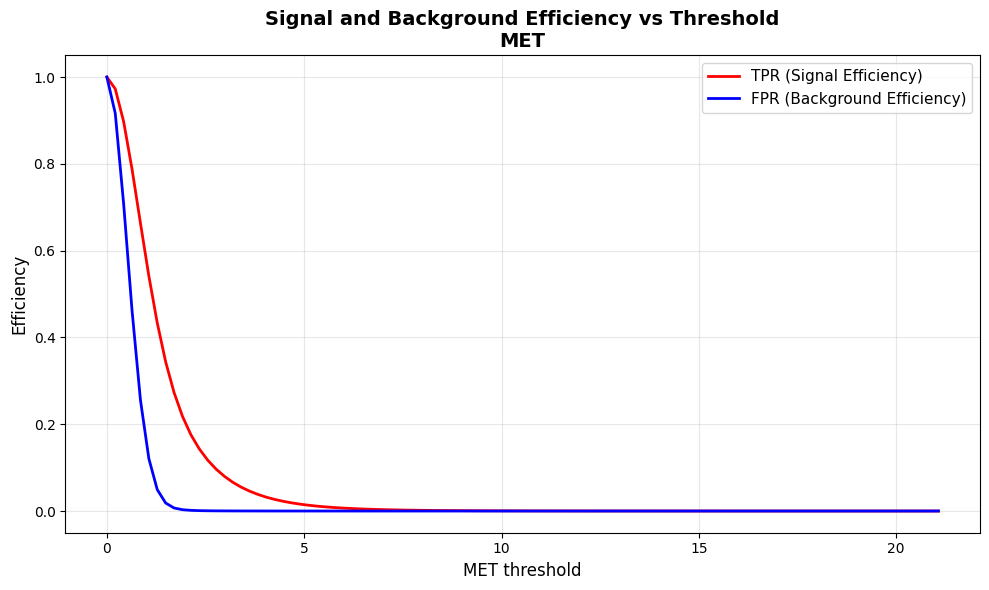

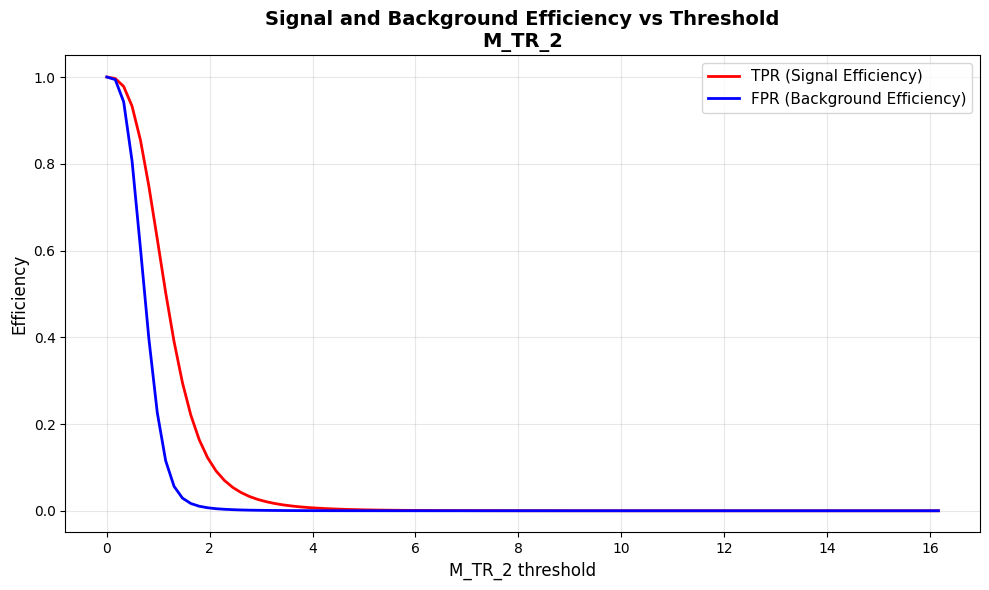

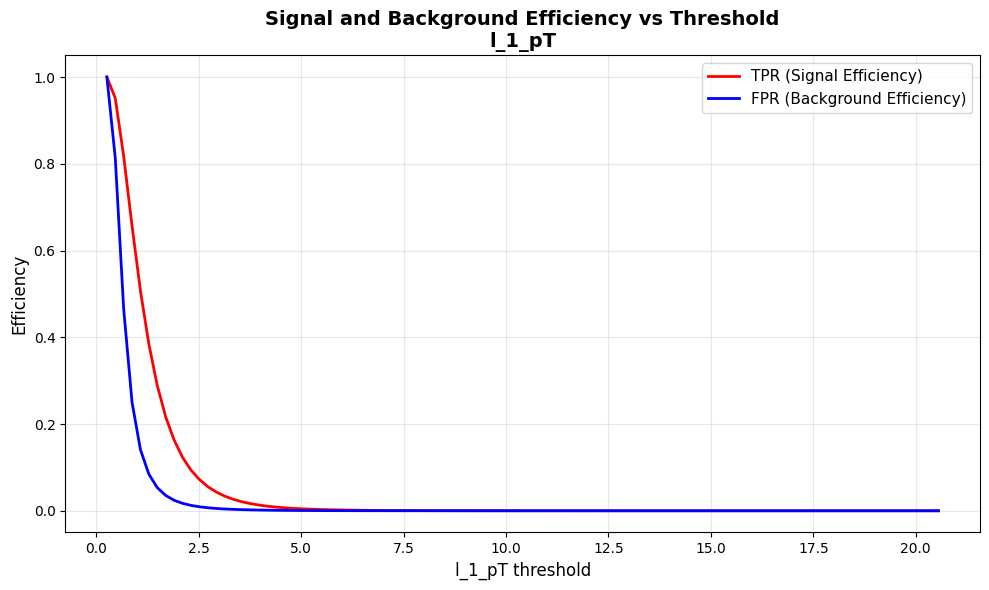

In [51]:
def calculate_tpr_fpr(df_sig, df_bkg, variable, selection_type=1, n_points=100):
    sig_data = df_sig[variable].values
    bkg_data = df_bkg[variable].values
    
    min_val = min(sig_data.min(), bkg_data.min())
    max_val = max(sig_data.max(), bkg_data.max())
    thresholds = np.linspace(min_val, max_val, n_points)
    
    tpr = []
    fpr = []
    
    for threshold in thresholds:
        if selection_type == 1:
            sig_pass = np.sum(sig_data > threshold)
            bkg_pass = np.sum(bkg_data > threshold)
        else:
            sig_pass = np.sum(sig_data < threshold)
            bkg_pass = np.sum(bkg_data < threshold)
        
        tpr.append(sig_pass / len(sig_data))
        fpr.append(bkg_pass / len(bkg_data))
    
    return thresholds, np.array(tpr), np.array(fpr)

def plot_tpr_fpr(df_sig, df_bkg, variable, selection_type):
    """Plot TPR and FPR vs threshold for a variable."""
    thresholds, tpr, fpr = calculate_tpr_fpr(df_sig, df_bkg, variable, selection_type)
    
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, tpr, 'r-', linewidth=2, label='TPR (Signal Efficiency)')
    plt.plot(thresholds, fpr, 'b-', linewidth=2, label='FPR (Background Efficiency)')
    plt.xlabel(f'{variable} threshold', fontsize=12)
    plt.ylabel('Efficiency', fontsize=12)
    plt.title(f'Signal and Background Efficiency vs Threshold\n{variable}', 
              fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

top_vars = [var for var, _ in sorted_sep[:3]]
for var in top_vars:
    sel_type = selection_criteria[var]
    plot_tpr_fpr(df_sig, df_bkg, var, sel_type)

/var/folders/93/3421lhhj2g17srkz5qmnhh8m0000gn/T/ipykernel_98994/2325846729.py:6: RuntimeWarning: invalid value encountered in divide
  significance = np.where(denominator > 0, N_S_prime / denominator, 0)


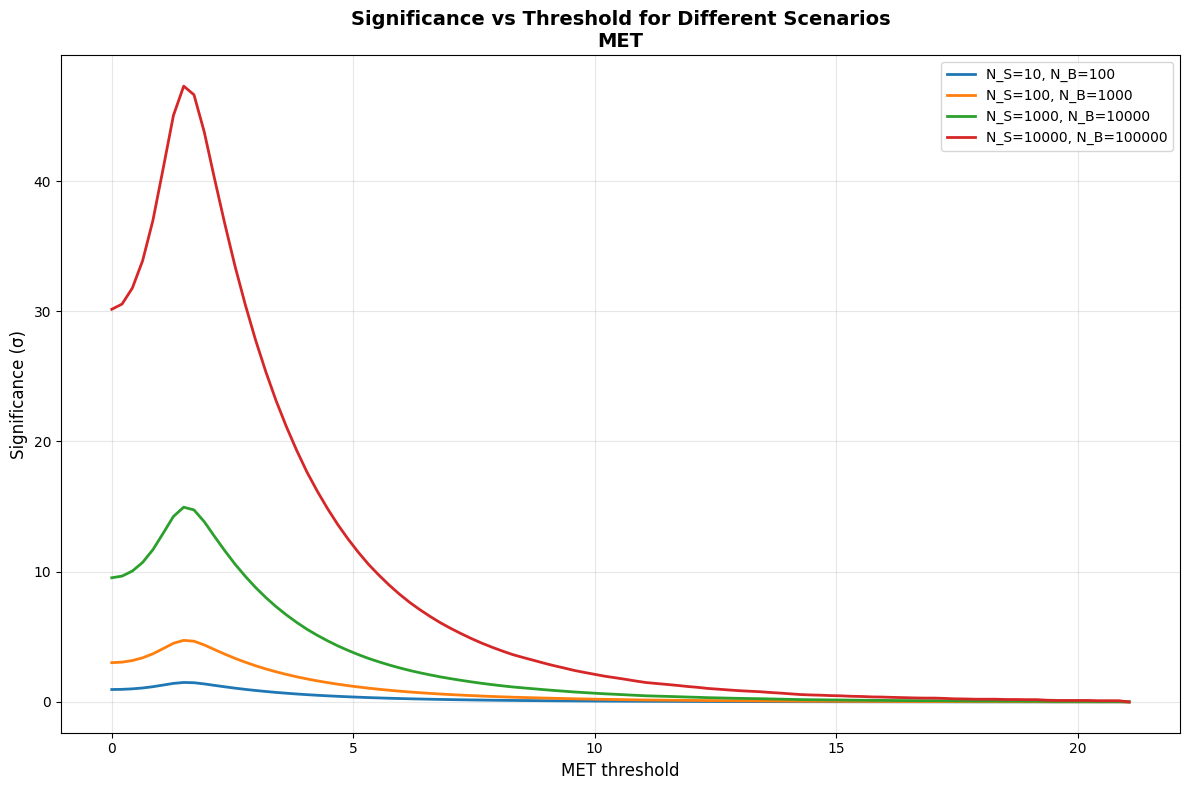


Optimal thresholds for MET:
N_S=10, N_B=100          : threshold=   1.490, σ= 1.495
N_S=100, N_B=1000        : threshold=   1.490, σ= 4.729
N_S=1000, N_B=10000      : threshold=   1.490, σ=14.954
N_S=10000, N_B=100000    : threshold=   1.490, σ=47.288


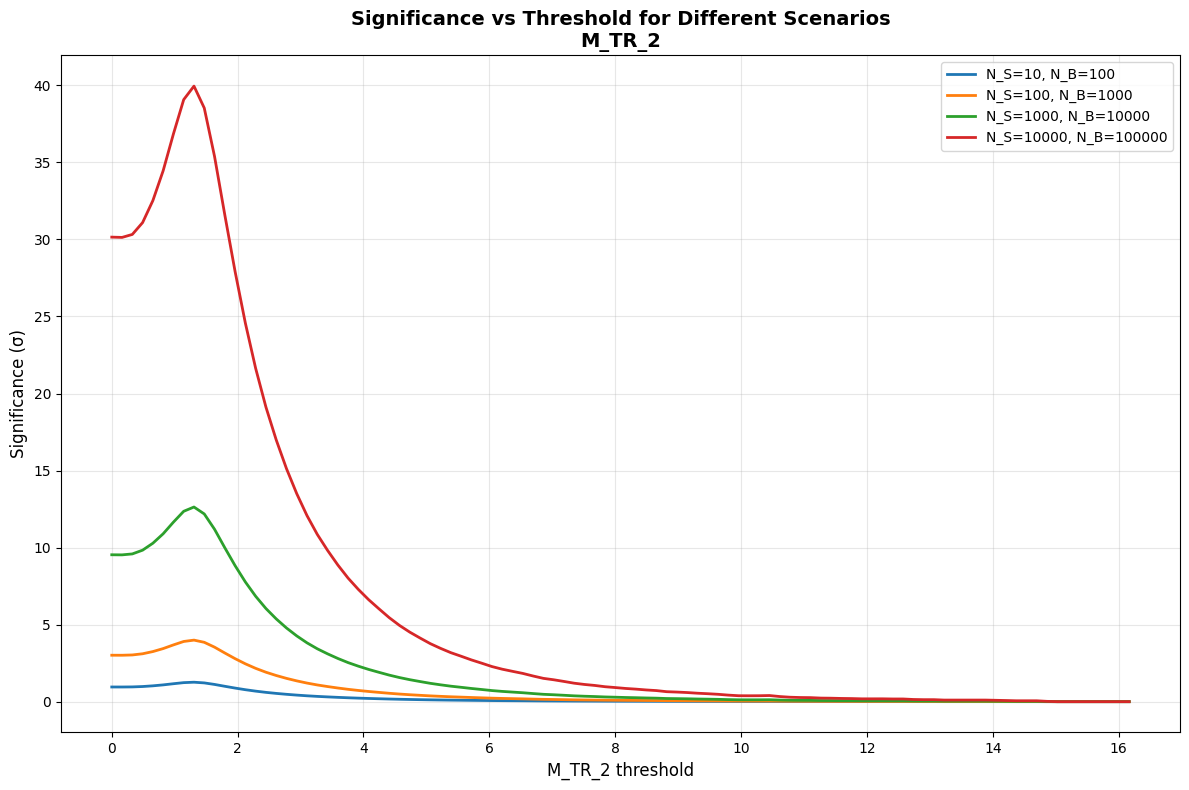


Optimal thresholds for M_TR_2:
N_S=10, N_B=100          : threshold=   1.307, σ= 1.263
N_S=100, N_B=1000        : threshold=   1.307, σ= 3.995
N_S=1000, N_B=10000      : threshold=   1.307, σ=12.634
N_S=10000, N_B=100000    : threshold=   1.307, σ=39.953


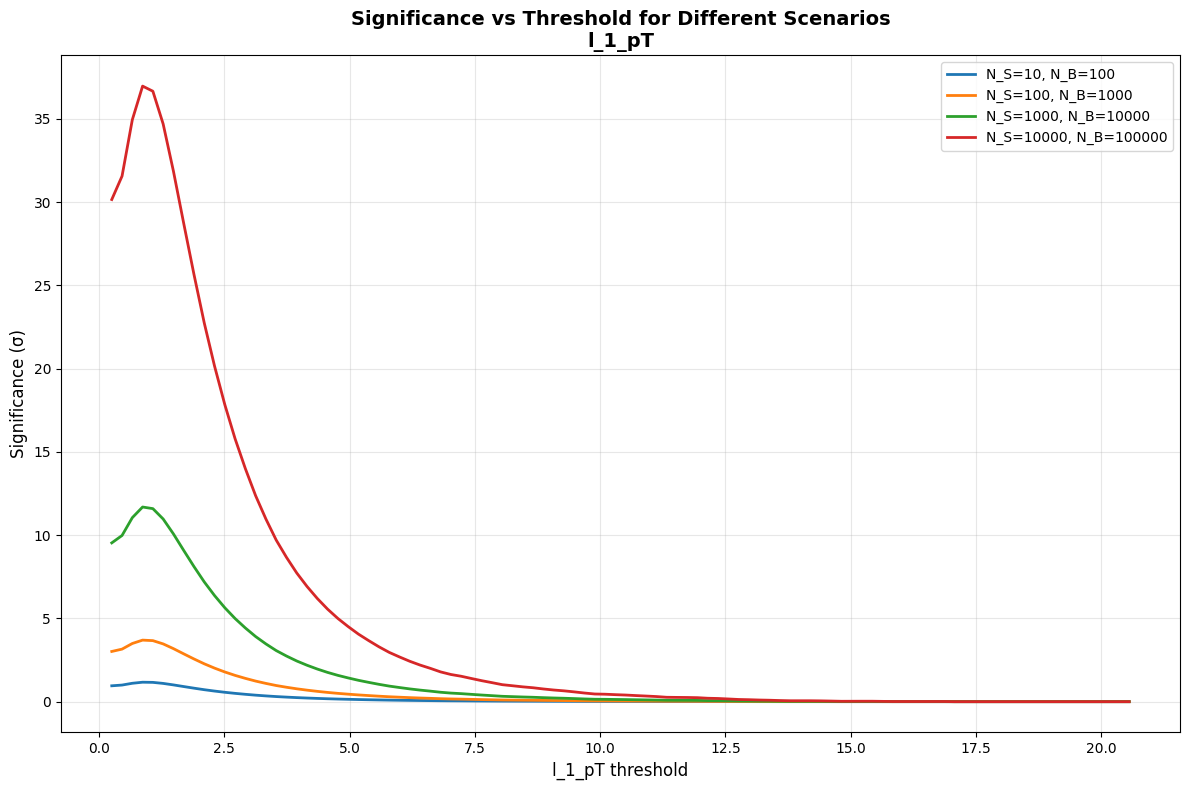


Optimal thresholds for l_1_pT:
N_S=10, N_B=100          : threshold=   0.870, σ= 1.169
N_S=100, N_B=1000        : threshold=   0.870, σ= 3.696
N_S=1000, N_B=10000      : threshold=   0.870, σ=11.688
N_S=10000, N_B=100000    : threshold=   0.870, σ=36.961


In [52]:
def calculate_significance(N_S, N_B, epsilon_S, epsilon_B):
    N_S_prime = epsilon_S * N_S
    N_B_prime = epsilon_B * N_B
    
    denominator = np.sqrt(N_S_prime + N_B_prime)
    significance = np.where(denominator > 0, N_S_prime / denominator, 0)
    
    return significance

def plot_significance_scenarios(df_sig, df_bkg, variable, selection_type):
    thresholds, tpr, fpr = calculate_tpr_fpr(df_sig, df_bkg, variable, selection_type)
    
    scenarios = [(10, 100, "N_S=10, N_B=100"), (100, 1000, "N_S=100, N_B=1000"), (1000, 10000, "N_S=1000, N_B=10000"), (10000, 100000, "N_S=10000, N_B=100000")]
    
    plt.figure(figsize=(12, 8))
    
    for N_S, N_B, label in scenarios:
        significance = calculate_significance(N_S, N_B, tpr, fpr)
        plt.plot(thresholds, significance, linewidth=2, label=label)
    
    plt.xlabel(f'{variable} threshold', fontsize=12)
    plt.ylabel('Significance (σ)', fontsize=12)
    plt.title(f'Significance vs Threshold for Different Scenarios\n{variable}', 
              fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nOptimal thresholds for {variable}:")
    for N_S, N_B, label in scenarios:
        significance = calculate_significance(N_S, N_B, tpr, fpr)
        optimal_idx = np.argmax(significance)
        optimal_threshold = thresholds[optimal_idx]
        max_significance = significance[optimal_idx]
        print(f"{label:25s}: threshold={optimal_threshold:8.3f}, σ={max_significance:6.3f}")

for var in top_vars:
    sel_type = selection_criteria[var]
    plot_significance_scenarios(df_sig, df_bkg, var, sel_type)

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [53]:
selected_vars = top_vars[:3]
print("Selected variables for cut flow:")
for i, var in enumerate(selected_vars, 1):
    print(f"{i}. {var}")

optimal_thresholds = {}

for var in selected_vars:
    sel_type = selection_criteria[var]
    thresholds, tpr, fpr = calculate_tpr_fpr(df_sig, df_bkg, var, sel_type)
    
    N_S, N_B = 1000, 10000
    significance = calculate_significance(N_S, N_B, tpr, fpr)
    
    optimal_idx = np.argmax(significance)
    optimal_thresholds[var] = thresholds[optimal_idx]
    
    print(f"\n{var}: optimal threshold = {thresholds[optimal_idx]:.3f}")

Selected variables for cut flow:
1. MET
2. M_TR_2
3. l_1_pT


/var/folders/93/3421lhhj2g17srkz5qmnhh8m0000gn/T/ipykernel_98994/2325846729.py:6: RuntimeWarning: invalid value encountered in divide
  significance = np.where(denominator > 0, N_S_prime / denominator, 0)



MET: optimal threshold = 1.490

M_TR_2: optimal threshold = 1.307

l_1_pT: optimal threshold = 0.870


In [54]:
def create_cutflow_table(df_sig, df_bkg, variables, thresholds, selection_types, N_S, N_B, scenario_name):
    sig_mask = np.ones(len(df_sig), dtype=bool)
    bkg_mask = np.ones(len(df_bkg), dtype=bool)
    
    cutflow_data = []
    
    epsilon_S = 1.0
    epsilon_B = 1.0
    N_S_prime = epsilon_S * N_S
    N_B_prime = epsilon_B * N_B
    significance = calculate_significance(N_S, N_B, epsilon_S, epsilon_B)
    
    cutflow_data.append(["No cuts", f"{epsilon_S:.4f}", f"{epsilon_B:.4f}", f"{N_S_prime:.1f}", f"{N_B_prime:.1f}", f"{significance:.3f}"])
    
    for var in variables:
        threshold = thresholds[var]
        sel_type = selection_types[var]
        
        if sel_type == 1:  # x > x_c
            sig_mask &= (df_sig[var].values > threshold)
            bkg_mask &= (df_bkg[var].values > threshold)
        else:  # x < x_c
            sig_mask &= (df_sig[var].values < threshold)
            bkg_mask &= (df_bkg[var].values < threshold)
        
        epsilon_S = np.sum(sig_mask) / len(df_sig)
        epsilon_B = np.sum(bkg_mask) / len(df_bkg)
        
        N_S_prime = epsilon_S * N_S
        N_B_prime = epsilon_B * N_B
        
        significance = calculate_significance(N_S, N_B, epsilon_S, epsilon_B)
        
        cutflow_data.append([var, f"{epsilon_S:.4f}", f"{epsilon_B:.4f}", f"{N_S_prime:.1f}", f"{N_B_prime:.1f}", f"{significance:.3f}"])
    
    headers = ["Cut", "ε_S", "ε_B", "N'_S", "N'_B", "σ"]
    
    print(f"CUT-FLOW TABLE - {scenario_name}")
    
    html_table = tabulate.tabulate(cutflow_data, headers=headers, tablefmt='html')
    display(HTML(html_table))
    
    print(tabulate.tabulate(cutflow_data, headers=headers, tablefmt='grid'))
    
    return cutflow_data

scenarios = [(10, 100, "Scenario 1: N_S=10, N_B=100"), (100, 1000, "Scenario 2: N_S=100, N_B=1000"), (1000, 10000, "Scenario 3: N_S=1000, N_B=10000"), (10000, 100000, "Scenario 4: N_S=10000, N_B=100000")]

for N_S, N_B, name in scenarios:
    create_cutflow_table(df_sig, df_bkg, selected_vars, optimal_thresholds, 
                        selection_criteria, N_S, N_B, name)

CUT-FLOW TABLE - Scenario 1: N_S=10, N_B=100


Cut,ε_S,ε_B,N'_S,N'_B,σ
No cuts,1,1,10,100,0.953
MET,0.3438,0.0185,3.4,1.8,1.495
M_TR_2,0.2487,0.0132,2.5,1.3,1.275
l_1_pT,0.2117,0.0094,2.1,0.9,1.21


+---------+--------+--------+--------+--------+-------+
| Cut     |    ε_S |    ε_B |   N'_S |   N'_B |     σ |
+=========+========+========+========+========+=======+
| No cuts | 1      | 1      |   10   |  100   | 0.953 |
+---------+--------+--------+--------+--------+-------+
| MET     | 0.3438 | 0.0185 |    3.4 |    1.8 | 1.495 |
+---------+--------+--------+--------+--------+-------+
| M_TR_2  | 0.2487 | 0.0132 |    2.5 |    1.3 | 1.275 |
+---------+--------+--------+--------+--------+-------+
| l_1_pT  | 0.2117 | 0.0094 |    2.1 |    0.9 | 1.21  |
+---------+--------+--------+--------+--------+-------+
CUT-FLOW TABLE - Scenario 2: N_S=100, N_B=1000


Cut,ε_S,ε_B,N'_S,N'_B,σ
No cuts,1,1,100,1000,3.015
MET,0.3438,0.0185,34.4,18.5,4.729
M_TR_2,0.2487,0.0132,24.9,13.2,4.031
l_1_pT,0.2117,0.0094,21.2,9.4,3.827


+---------+--------+--------+--------+--------+-------+
| Cut     |    ε_S |    ε_B |   N'_S |   N'_B |     σ |
+=========+========+========+========+========+=======+
| No cuts | 1      | 1      |  100   | 1000   | 3.015 |
+---------+--------+--------+--------+--------+-------+
| MET     | 0.3438 | 0.0185 |   34.4 |   18.5 | 4.729 |
+---------+--------+--------+--------+--------+-------+
| M_TR_2  | 0.2487 | 0.0132 |   24.9 |   13.2 | 4.031 |
+---------+--------+--------+--------+--------+-------+
| l_1_pT  | 0.2117 | 0.0094 |   21.2 |    9.4 | 3.827 |
+---------+--------+--------+--------+--------+-------+
CUT-FLOW TABLE - Scenario 3: N_S=1000, N_B=10000


Cut,ε_S,ε_B,N'_S,N'_B,σ
No cuts,1,1,1000,10000,9.535
MET,0.3438,0.0185,343.8,184.8,14.954
M_TR_2,0.2487,0.0132,248.7,131.8,12.748
l_1_pT,0.2117,0.0094,211.7,94.3,12.103


+---------+--------+--------+--------+---------+--------+
| Cut     |    ε_S |    ε_B |   N'_S |    N'_B |      σ |
+=========+========+========+========+=========+========+
| No cuts | 1      | 1      | 1000   | 10000   |  9.535 |
+---------+--------+--------+--------+---------+--------+
| MET     | 0.3438 | 0.0185 |  343.8 |   184.8 | 14.954 |
+---------+--------+--------+--------+---------+--------+
| M_TR_2  | 0.2487 | 0.0132 |  248.7 |   131.8 | 12.748 |
+---------+--------+--------+--------+---------+--------+
| l_1_pT  | 0.2117 | 0.0094 |  211.7 |    94.3 | 12.103 |
+---------+--------+--------+--------+---------+--------+
CUT-FLOW TABLE - Scenario 4: N_S=10000, N_B=100000


Cut,ε_S,ε_B,N'_S,N'_B,σ
No cuts,1,1,10000,100000,30.151
MET,0.3438,0.0185,3438.3,1848.4,47.288
M_TR_2,0.2487,0.0132,2486.6,1318.3,40.312
l_1_pT,0.2117,0.0094,2117.4,943.1,38.274


+---------+--------+--------+---------+----------+--------+
| Cut     |    ε_S |    ε_B |    N'_S |     N'_B |      σ |
+=========+========+========+=========+==========+========+
| No cuts | 1      | 1      | 10000   | 100000   | 30.151 |
+---------+--------+--------+---------+----------+--------+
| MET     | 0.3438 | 0.0185 |  3438.3 |   1848.4 | 47.288 |
+---------+--------+--------+---------+----------+--------+
| M_TR_2  | 0.2487 | 0.0132 |  2486.6 |   1318.3 | 40.312 |
+---------+--------+--------+---------+----------+--------+
| l_1_pT  | 0.2117 | 0.0094 |  2117.4 |    943.1 | 38.274 |
+---------+--------+--------+---------+----------+--------+


In [55]:
def analyze_correlation_effect(df_sig, df_bkg, var1, var2, N_S=1000, N_B=10000):
    print(f"CORRELATION EFFECT ANALYSIS")
    print(f"Variables: {var1} and {var2}")
    
    corr = df[var1].corr(df[var2])
    print(f"Correlation coefficient: {corr:.3f}")
    
    print(f"\nScenario 1: Cut on {var1} first, then optimize {var2}")
    print("-"*70)
    
    sel_type1 = selection_criteria[var1]
    threshold1 = optimal_thresholds[var1]
    
    if sel_type1 == 1:
        sig_after_cut1 = df_sig[df_sig[var1] > threshold1]
        bkg_after_cut1 = df_bkg[df_bkg[var1] > threshold1]
    else:
        sig_after_cut1 = df_sig[df_sig[var1] < threshold1]
        bkg_after_cut1 = df_bkg[df_bkg[var1] < threshold1]
    
    sel_type2 = selection_criteria[var2]
    thresholds2, tpr2, fpr2 = calculate_tpr_fpr(sig_after_cut1, bkg_after_cut1, 
                                                 var2, sel_type2)
    
    epsilon_S1 = len(sig_after_cut1) / len(df_sig)
    epsilon_B1 = len(bkg_after_cut1) / len(df_bkg)
    
    significance1 = calculate_significance(N_S, N_B, tpr2 * epsilon_S1, fpr2 * epsilon_B1)
    optimal_idx1 = np.argmax(significance1)
    
    print(f"Optimal {var2} threshold after {var1} cut: {thresholds2[optimal_idx1]:.3f}")
    print(f"Maximum significance: {significance1[optimal_idx1]:.3f}")
    
    print(f"\nScenario 2: Cut on {var2} first, then optimize {var1}")
    print("-"*70)
    
    threshold2 = optimal_thresholds[var2]
    
    if sel_type2 == 1:
        sig_after_cut2 = df_sig[df_sig[var2] > threshold2]
        bkg_after_cut2 = df_bkg[df_bkg[var2] > threshold2]
    else:
        sig_after_cut2 = df_sig[df_sig[var2] < threshold2]
        bkg_after_cut2 = df_bkg[df_bkg[var2] < threshold2]
    
    thresholds1, tpr1, fpr1 = calculate_tpr_fpr(sig_after_cut2, bkg_after_cut2, var1, sel_type1)
    
    epsilon_S2 = len(sig_after_cut2) / len(df_sig)
    epsilon_B2 = len(bkg_after_cut2) / len(df_bkg)
    
    significance2 = calculate_significance(N_S, N_B, tpr1 * epsilon_S2, fpr1 * epsilon_B2)
    optimal_idx2 = np.argmax(significance2)
    
    print(f"Optimal {var1} threshold after {var2} cut: {thresholds1[optimal_idx2]:.3f}")
    print(f"Maximum significance: {significance2[optimal_idx2]:.3f}")
    
    print(f"\nComparison:")
    print("-"*70)
    print(f"{var1} → {var2}: σ = {significance1[optimal_idx1]:.3f}")
    print(f"{var2} → {var1}: σ = {significance2[optimal_idx2]:.3f}")
    
    if abs(corr) > 0.5:
        print(f"\n High correlation ({corr:.3f}) - cut order matters!")
    else:
        print(f"\n Low correlation ({corr:.3f}) - cut order less important")

if len(selected_vars) >= 2:
    analyze_correlation_effect(df_sig, df_bkg, selected_vars[0], selected_vars[1])

CORRELATION EFFECT ANALYSIS
Variables: MET and M_TR_2
Correlation coefficient: 0.722

Scenario 1: Cut on MET first, then optimize M_TR_2
----------------------------------------------------------------------
Optimal M_TR_2 threshold after MET cut: 0.004
Maximum significance: 14.954

Scenario 2: Cut on M_TR_2 first, then optimize MET
----------------------------------------------------------------------
Optimal MET threshold after M_TR_2 cut: 1.421
Maximum significance: 12.754

Comparison:
----------------------------------------------------------------------
MET → M_TR_2: σ = 14.954
M_TR_2 → MET: σ = 12.754

 High correlation (0.722) - cut order matters!


/var/folders/93/3421lhhj2g17srkz5qmnhh8m0000gn/T/ipykernel_98994/2325846729.py:6: RuntimeWarning: invalid value encountered in divide
  significance = np.where(denominator > 0, N_S_prime / denominator, 0)


## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



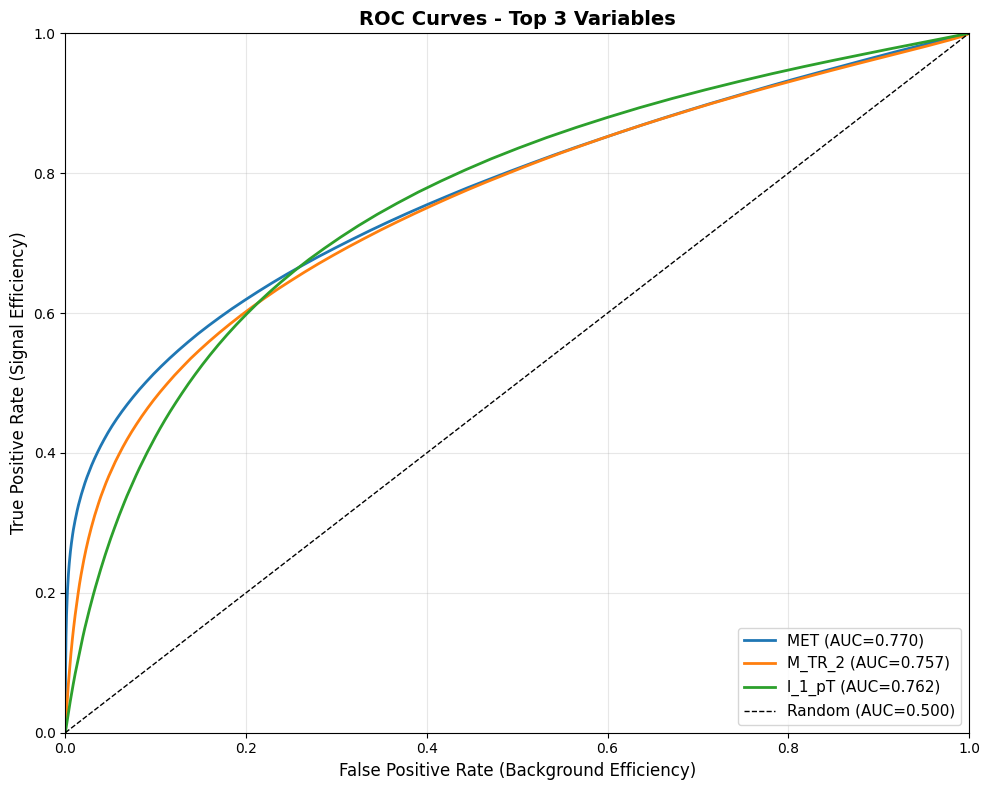


Area Under Curve (AUC) Scores:
MET            : 0.7701
M_TR_2         : 0.7573
l_1_pT         : 0.7620


In [57]:
from sklearn.metrics import auc

def calculate_roc(df_sig, df_bkg, variable, n_points=1000):
    sig_data = df_sig[variable].values
    bkg_data = df_bkg[variable].values
    
    if sig_data.mean() > bkg_data.mean():
        reverse = True
    else:
        reverse = False
    
    all_values = np.concatenate([sig_data, bkg_data])
    thresholds = np.linspace(all_values.min(), all_values.max(), n_points)
    
    fpr_array = []
    tpr_array = []
    
    for threshold in thresholds:
        if reverse:
            tpr = np.sum(sig_data > threshold) / len(sig_data)
            fpr = np.sum(bkg_data > threshold) / len(bkg_data)
        else:
            tpr = np.sum(sig_data < threshold) / len(sig_data)
            fpr = np.sum(bkg_data < threshold) / len(bkg_data)
        
        fpr_array.append(fpr)
        tpr_array.append(tpr)
    
    fpr_array = np.array(fpr_array)
    tpr_array = np.array(tpr_array)
    
    sorted_indices = np.argsort(fpr_array)
    fpr_sorted = fpr_array[sorted_indices]
    tpr_sorted = tpr_array[sorted_indices]
    
    auc_score = auc(fpr_sorted, tpr_sorted)
    
    return fpr_sorted, tpr_sorted, auc_score

plt.figure(figsize=(10, 8))

for var in top_vars:
    fpr, tpr, auc_score = calculate_roc(df_sig, df_bkg, var)
    plt.plot(fpr, tpr, linewidth=2, label=f'{var} (AUC={auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')

plt.xlabel('False Positive Rate (Background Efficiency)', fontsize=12)
plt.ylabel('True Positive Rate (Signal Efficiency)', fontsize=12)
plt.title('ROC Curves - Top 3 Variables', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

print("\nArea Under Curve (AUC) Scores:")
for var in top_vars:
    _, _, auc_score = calculate_roc(df_sig, df_bkg, var)
    print(f"{var:15s}: {auc_score:.4f}")

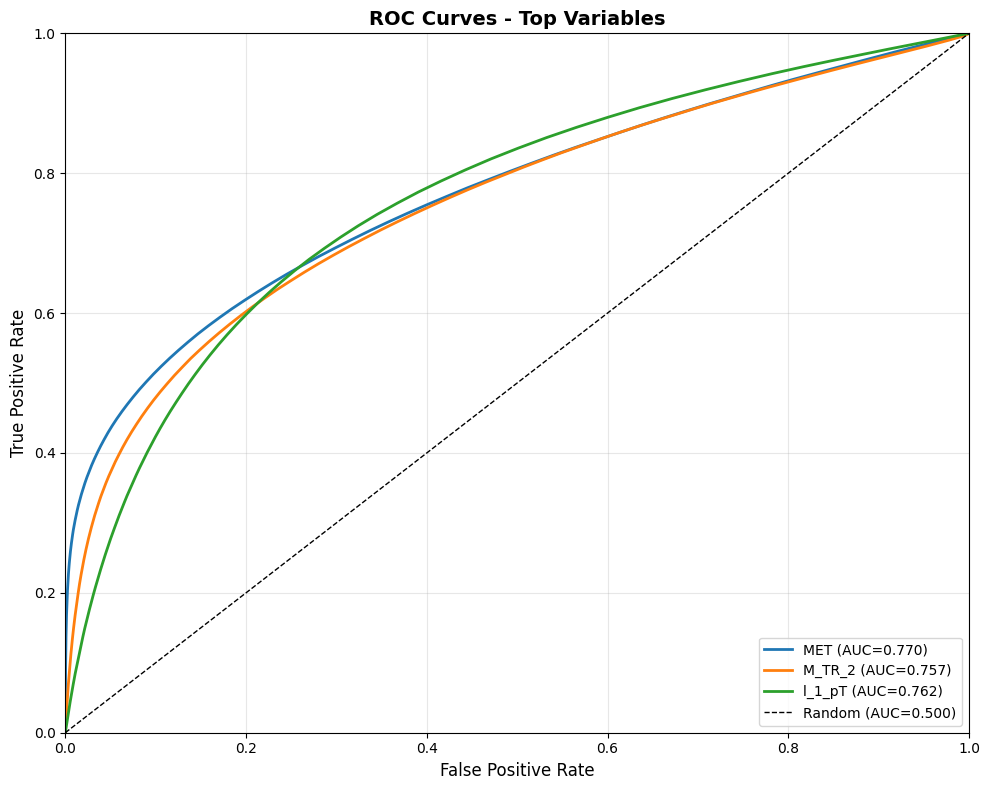

In [59]:
def plot_roc_curves(df_sig, df_bkg, variables, title="ROC Curves", figsize=(10, 8), show_random=True):
    plt.figure(figsize=figsize)
    
    auc_scores = {}
    
    for var in variables:
        fpr, tpr, auc_score = calculate_roc(df_sig, df_bkg, var)
        auc_scores[var] = auc_score
        plt.plot(fpr, tpr, linewidth=2, label=f'{var} (AUC={auc_score:.3f})')
    
    if show_random:
        plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
    
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(fontsize=10, loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.tight_layout()
    plt.show()
    
    return auc_scores

auc_results = plot_roc_curves(df_sig, df_bkg, top_vars, title="ROC Curves - Top Variables")

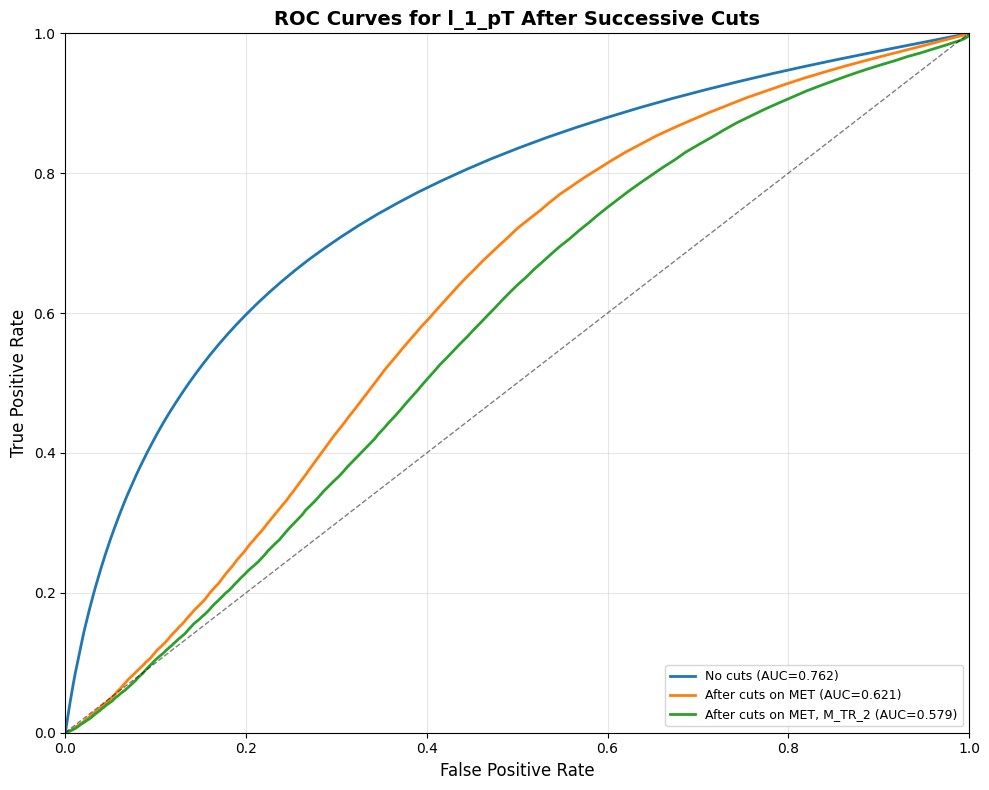

In [60]:
def plot_roc_after_cuts(df_sig, df_bkg, cut_variables, test_variable, thresholds, selection_types):
    plt.figure(figsize=(10, 8))
    
    fpr0, tpr0, auc0 = calculate_roc(df_sig, df_bkg, test_variable)
    plt.plot(fpr0, tpr0, linewidth=2, label=f'No cuts (AUC={auc0:.3f})')
    
    sig_current = df_sig.copy()
    bkg_current = df_bkg.copy()
    
    for i, cut_var in enumerate(cut_variables):
        threshold = thresholds[cut_var]
        sel_type = selection_types[cut_var]
        
        if sel_type == 1:
            sig_current = sig_current[sig_current[cut_var] > threshold]
            bkg_current = bkg_current[bkg_current[cut_var] > threshold]
        else:
            sig_current = sig_current[sig_current[cut_var] < threshold]
            bkg_current = bkg_current[bkg_current[cut_var] < threshold]
        
        fpr, tpr, auc_score = calculate_roc(sig_current, bkg_current, test_variable)
        
        cut_list = ', '.join(cut_variables[:i+1])
        plt.plot(fpr, tpr, linewidth=2, label=f'After cuts on {cut_list} (AUC={auc_score:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves for {test_variable} After Successive Cuts', fontsize=14, fontweight='bold')
    plt.legend(fontsize=9, loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.tight_layout()
    plt.show()

if len(selected_vars) >= 3:
    plot_roc_after_cuts(df_sig, df_bkg, selected_vars[:2], selected_vars[2], optimal_thresholds, selection_criteria)

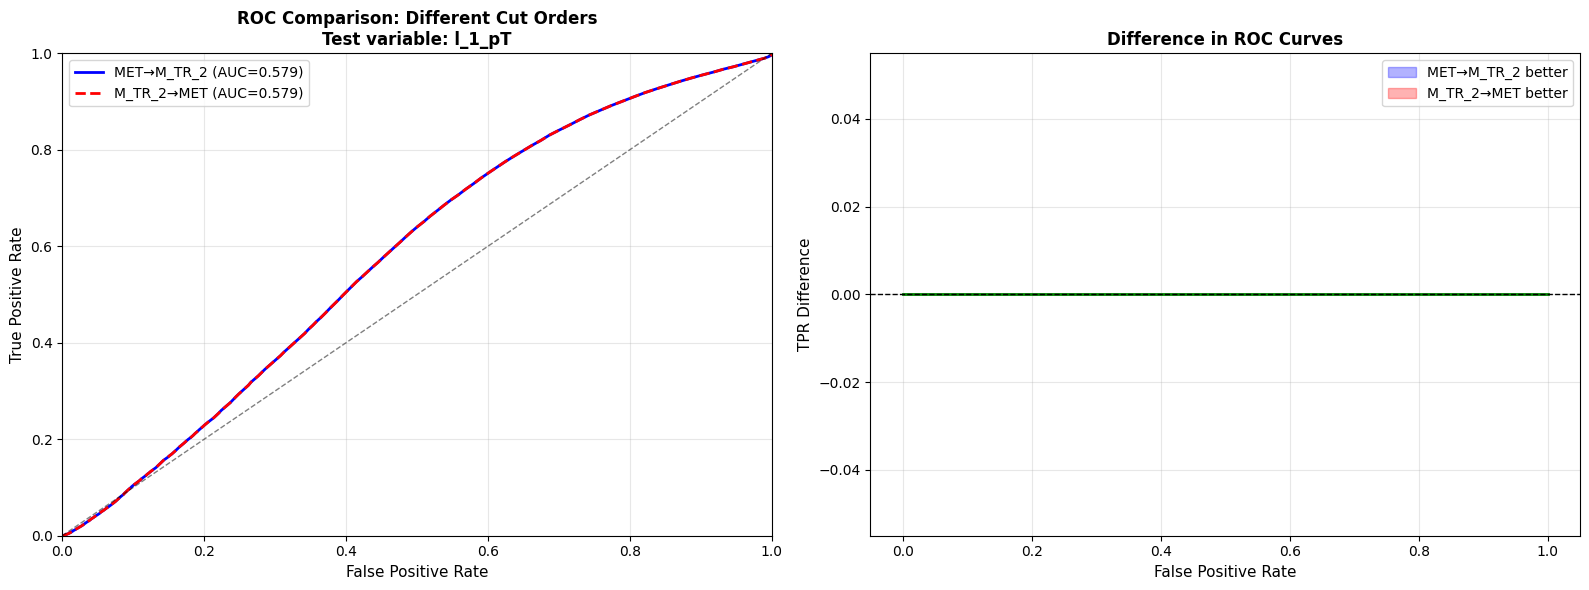

AUC Difference: 0.0000
Cut order has minimal effect (difference < 0.01)


In [61]:
def compare_cut_orders(df_sig, df_bkg, var1, var2, test_var, thresholds, selection_types):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    sig_temp = df_sig.copy()
    bkg_temp = df_bkg.copy()
    
    if selection_types[var1] == 1:
        sig_temp = sig_temp[sig_temp[var1] > thresholds[var1]]
        bkg_temp = bkg_temp[bkg_temp[var1] > thresholds[var1]]
    else:
        sig_temp = sig_temp[sig_temp[var1] < thresholds[var1]]
        bkg_temp = bkg_temp[bkg_temp[var1] < thresholds[var1]]
    
    if selection_types[var2] == 1:
        sig_order1 = sig_temp[sig_temp[var2] > thresholds[var2]]
        bkg_order1 = bkg_temp[bkg_temp[var2] > thresholds[var2]]
    else:
        sig_order1 = sig_temp[sig_temp[var2] < thresholds[var2]]
        bkg_order1 = bkg_temp[bkg_temp[var2] < thresholds[var2]]
    
    fpr1, tpr1, auc1 = calculate_roc(sig_order1, bkg_order1, test_var)
    
    sig_temp = df_sig.copy()
    bkg_temp = df_bkg.copy()
    
    if selection_types[var2] == 1:
        sig_temp = sig_temp[sig_temp[var2] > thresholds[var2]]
        bkg_temp = bkg_temp[bkg_temp[var2] > thresholds[var2]]
    else:
        sig_temp = sig_temp[sig_temp[var2] < thresholds[var2]]
        bkg_temp = bkg_temp[bkg_temp[var2] < thresholds[var2]]
    
    if selection_types[var1] == 1:
        sig_order2 = sig_temp[sig_temp[var1] > thresholds[var1]]
        bkg_order2 = bkg_temp[bkg_temp[var1] > thresholds[var1]]
    else:
        sig_order2 = sig_temp[sig_temp[var1] < thresholds[var1]]
        bkg_order2 = bkg_temp[bkg_temp[var1] < thresholds[var1]]
    
    fpr2, tpr2, auc2 = calculate_roc(sig_order2, bkg_order2, test_var)
    
    ax1.plot(fpr1, tpr1, 'b-', linewidth=2, label=f'{var1}→{var2} (AUC={auc1:.3f})')
    ax1.plot(fpr2, tpr2, 'r--', linewidth=2, label=f'{var2}→{var1} (AUC={auc2:.3f})')
    ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
    ax1.set_xlabel('False Positive Rate', fontsize=11)
    ax1.set_ylabel('True Positive Rate', fontsize=11)
    ax1.set_title(f'ROC Comparison: Different Cut Orders\nTest variable: {test_var}', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([0, 1])
    ax1.set_ylim([0, 1])
    
    from scipy.interpolate import interp1d
    
    fpr_common = np.linspace(0, 1, 100)
    
    interp1 = interp1d(fpr1, tpr1, kind='linear', fill_value='extrapolate')
    interp2 = interp1d(fpr2, tpr2, kind='linear', fill_value='extrapolate')
    
    tpr1_interp = interp1(fpr_common)
    tpr2_interp = interp2(fpr_common)
    
    difference = tpr1_interp - tpr2_interp
    
    ax2.plot(fpr_common, difference, 'g-', linewidth=2)
    ax2.axhline(y=0, color='k', linestyle='--', linewidth=1)
    ax2.fill_between(fpr_common, 0, difference, where=(difference > 0), alpha=0.3, color='blue', label=f'{var1}→{var2} better')
    ax2.fill_between(fpr_common, 0, difference, where=(difference < 0), alpha=0.3, color='red', label=f'{var2}→{var1} better')
    ax2.set_xlabel('False Positive Rate', fontsize=11)
    ax2.set_ylabel('TPR Difference', fontsize=11)
    ax2.set_title('Difference in ROC Curves', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"AUC Difference: {abs(auc1 - auc2):.4f}")
    if abs(auc1 - auc2) < 0.01:
        print("Cut order has minimal effect (difference < 0.01)")
    else:
        print("Cut order matters! (difference ≥ 0.01)")

if len(selected_vars) >= 3:
    compare_cut_orders(df_sig, df_bkg, selected_vars[0], selected_vars[1], selected_vars[2], optimal_thresholds, selection_criteria)

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.2

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.3

Draw the ROC curve for $F_n$. 

### Exercise 8.4

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [62]:
def compute_lda_matrices(df_sig, df_bkg, var_names):
    X_sig = df_sig[var_names].values
    X_bkg = df_bkg[var_names].values
    
    m_1 = np.mean(X_bkg, axis=0)
    m_2 = np.mean(X_sig, axis=0)
    
    mean_diff = (m_2 - m_1).reshape(-1, 1)
    S_B = mean_diff @ mean_diff.T
    
    S_W = np.zeros((len(var_names), len(var_names)))
    
    for x_n in X_bkg:
        diff = (x_n - m_1).reshape(-1, 1)
        S_W += diff @ diff.T
    
    for x_n in X_sig:
        diff = (x_n - m_2).reshape(-1, 1)
        S_W += diff @ diff.T
    
    return S_B, S_W, m_1, m_2

print("Computing Linear Discriminant Analysis matrices...")

all_features = VarNames[1:]
S_B, S_W, m_bkg, m_sig = compute_lda_matrices(df_sig, df_bkg, all_features)

print(f" S_B shape: {S_B.shape}")
print(f" S_W shape: {S_W.shape}")
print(f" Mean vector (signal) shape: {m_sig.shape}")
print(f" Mean vector (background) shape: {m_bkg.shape}")

print("\nMean values (first 5 features):")
for i, var in enumerate(all_features[:5]):
    print(f"{var:15s}: Signal={m_sig[i]:8.3f}, Background={m_bkg[i]:8.3f}")

Computing Linear Discriminant Analysis matrices...
 S_B shape: (18, 18)
 S_W shape: (18, 18)
 Mean vector (signal) shape: (18,)
 Mean vector (background) shape: (18,)

Mean values (first 5 features):
l_1_pT         : Signal=   1.290, Background=   0.756
l_1_eta        : Signal=  -0.000, Background=   0.000
l_1_phi        : Signal=  -0.001, Background=   0.000
l_2_pT         : Signal=   1.138, Background=   0.882
l_2_eta        : Signal=   0.000, Background=  -0.000


In [63]:
def compute_fisher_discriminant(S_W, m_1, m_2):
    mean_diff = m_2 - m_1
    
    try:
        S_W_inv = np.linalg.inv(S_W)
        w = S_W_inv @ mean_diff
    except np.linalg.LinAlgError:
        print("Warning: S_W is singular, using pseudo-inverse")
        S_W_inv = np.linalg.pinv(S_W)
        w = S_W_inv @ mean_diff
    
    return w

w = compute_fisher_discriminant(S_W, m_bkg, m_sig)

print("\nFisher Linear Discriminant Weights:")
for i, var in enumerate(all_features):
    print(f"{var:15s}: {w[i]:10.5f}")

w_normalized = w / np.linalg.norm(w)
print("\nNormalized weights (unit vector):")
for i, var in enumerate(all_features):
    print(f"{var:15s}: {w_normalized[i]:10.5f}")


Fisher Linear Discriminant Weights:
l_1_pT         :    0.00000
l_1_eta        :   -0.00000
l_1_phi        :   -0.00000
l_2_pT         :    0.00000
l_2_eta        :    0.00000
l_2_phi        :   -0.00000
MET            :    0.00000
MET_phi        :    0.00000
MET_rel        :    0.00000
axial_MET      :    0.00000
M_R            :   -0.00000
M_TR_2         :    0.00000
R              :   -0.00000
MT2            :   -0.00000
S_R            :   -0.00000
M_Delta_R      :    0.00000
dPhi_r_b       :   -0.00000
cos_theta_r1   :    0.00000

Normalized weights (unit vector):
l_1_pT         :    0.32674
l_1_eta        :   -0.00013
l_1_phi        :   -0.00063
l_2_pT         :    0.15349
l_2_eta        :    0.00033
l_2_phi        :   -0.00005
MET            :    0.24163
MET_phi        :    0.00058
MET_rel        :    0.02081
axial_MET      :    0.04001
M_R            :   -0.03777
M_TR_2         :    0.01608
R              :   -0.30502
MT2            :   -0.04969
S_R            :   -0.27113
M_De

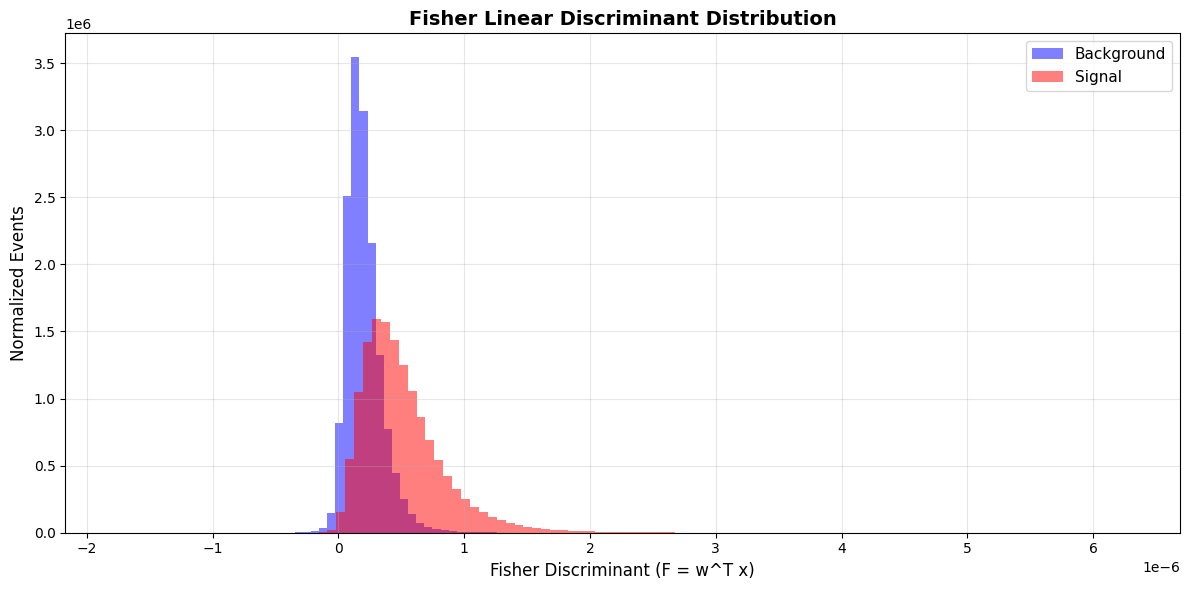


Fisher Discriminant Statistics:
Signal mean:          0.0000 ±     0.0000
Background mean:      0.0000 ±     0.0000
Separation:           1.2029


In [64]:
def compute_discriminant_values(df, var_names, w):
    X = df[var_names].values
    F = X @ w
    return F

F_sig = compute_discriminant_values(df_sig, all_features, w)
F_bkg = compute_discriminant_values(df_bkg, all_features, w)

plt.figure(figsize=(12, 6))

plt.hist(F_bkg, bins=100, alpha=0.5, color='blue', label='Background', density=True, histtype='stepfilled')
plt.hist(F_sig, bins=100, alpha=0.5, color='red', label='Signal', density=True, histtype='stepfilled')

plt.xlabel('Fisher Discriminant (F = w^T x)', fontsize=12)
plt.ylabel('Normalized Events', fontsize=12)
plt.title('Fisher Linear Discriminant Distribution', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

mean_F_sig = np.mean(F_sig)
mean_F_bkg = np.mean(F_bkg)
std_F_sig = np.std(F_sig)
std_F_bkg = np.std(F_bkg)

separation = abs(mean_F_sig - mean_F_bkg) / np.sqrt((std_F_sig**2 + std_F_bkg**2) / 2)

print("\nFisher Discriminant Statistics:")
print(f"Signal mean:      {mean_F_sig:10.4f} ± {std_F_sig:10.4f}")
print(f"Background mean:  {mean_F_bkg:10.4f} ± {std_F_bkg:10.4f}")
print(f"Separation:       {separation:10.4f}")

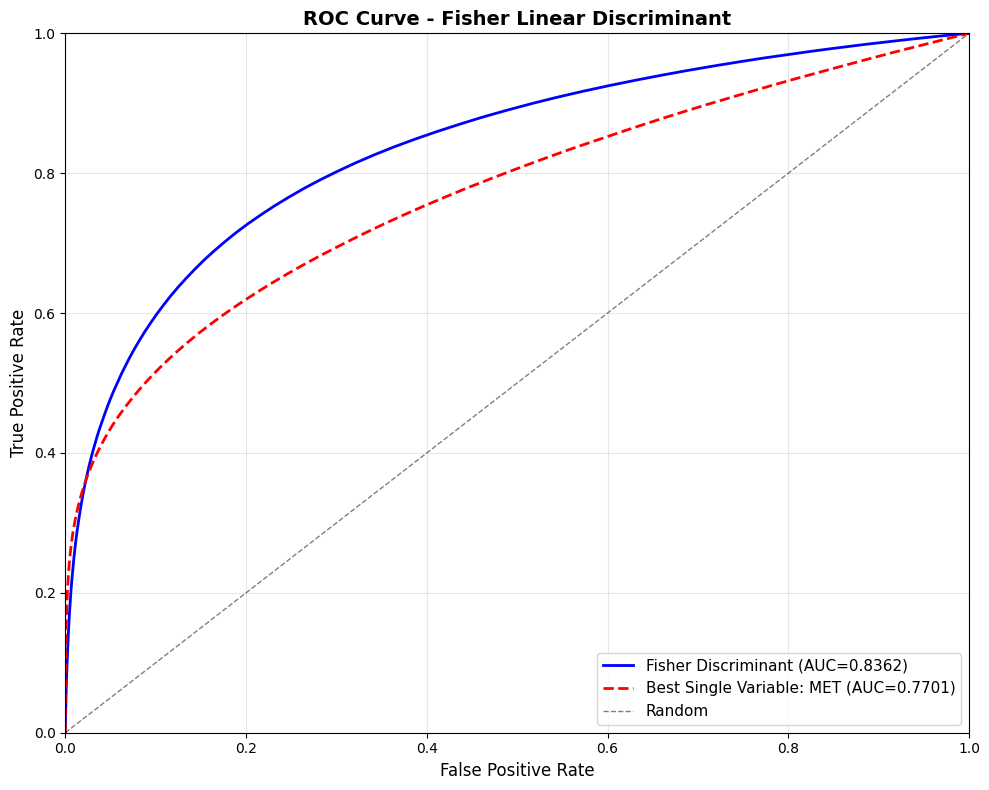


ROC Curve Comparison:
Fisher Discriminant AUC: 0.8362
Best Single Variable (MET) AUC: 0.7701
Improvement: 0.0661


In [65]:
df_sig_temp = df_sig.copy()
df_bkg_temp = df_bkg.copy()
df_sig_temp['fisher_discriminant'] = F_sig
df_bkg_temp['fisher_discriminant'] = F_bkg

fpr_fisher, tpr_fisher, auc_fisher = calculate_roc(df_sig_temp, df_bkg_temp, 'fisher_discriminant')

plt.figure(figsize=(10, 8))

plt.plot(fpr_fisher, tpr_fisher, 'b-', linewidth=2, label=f'Fisher Discriminant (AUC={auc_fisher:.4f})')

best_var = top_vars[0]
fpr_best, tpr_best, auc_best = calculate_roc(df_sig, df_bkg, best_var)
plt.plot(fpr_best, tpr_best, 'r--', linewidth=2, label=f'Best Single Variable: {best_var} (AUC={auc_best:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Fisher Linear Discriminant', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

print("\nROC Curve Comparison:")
print(f"Fisher Discriminant AUC: {auc_fisher:.4f}")
print(f"Best Single Variable ({best_var}) AUC: {auc_best:.4f}")
print(f"Improvement: {(auc_fisher - auc_best):.4f}")


Maximum Significance - Fisher Discriminant:


/var/folders/93/3421lhhj2g17srkz5qmnhh8m0000gn/T/ipykernel_98994/2325846729.py:6: RuntimeWarning: invalid value encountered in divide
  significance = np.where(denominator > 0, N_S_prime / denominator, 0)


N_S=10, N_B=100               : σ_max =  1.527, threshold =    0.000
N_S=100, N_B=1000             : σ_max =  4.830, threshold =    0.000
N_S=1000, N_B=10000           : σ_max = 15.274, threshold =    0.000
N_S=10000, N_B=100000         : σ_max = 48.300, threshold =    0.000


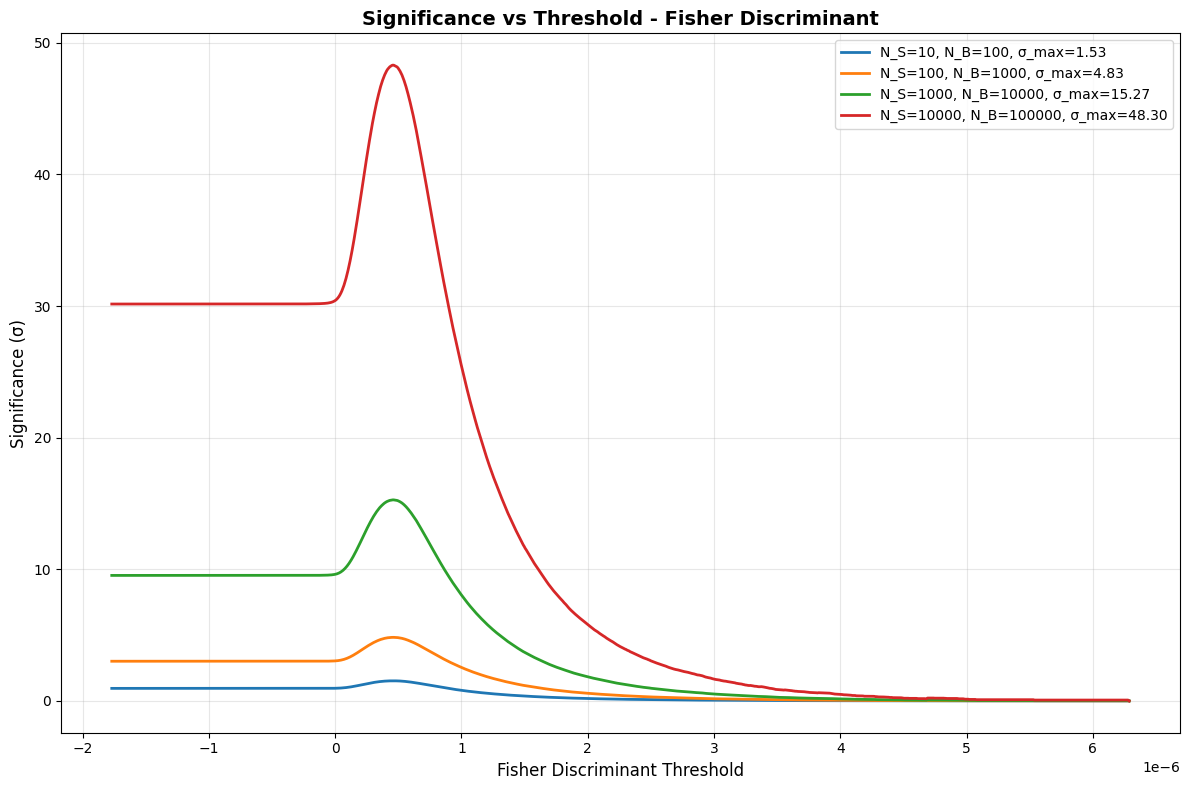

In [66]:
def find_optimal_significance_fisher(F_sig, F_bkg, N_S, N_B, n_points=1000):
    F_all = np.concatenate([F_sig, F_bkg])
    thresholds = np.linspace(F_all.min(), F_all.max(), n_points)
    
    if F_sig.mean() > F_bkg.mean():
        epsilon_S = np.array([np.sum(F_sig > t) / len(F_sig) for t in thresholds])
        epsilon_B = np.array([np.sum(F_bkg > t) / len(F_bkg) for t in thresholds])
    else:
        epsilon_S = np.array([np.sum(F_sig < t) / len(F_sig) for t in thresholds])
        epsilon_B = np.array([np.sum(F_bkg < t) / len(F_bkg) for t in thresholds])
    
    significance = calculate_significance(N_S, N_B, epsilon_S, epsilon_B)
    
    max_idx = np.argmax(significance)
    max_significance = significance[max_idx]
    optimal_threshold = thresholds[max_idx]
    
    return max_significance, optimal_threshold, thresholds, significance

print("\nMaximum Significance - Fisher Discriminant:")

scenarios = [(10, 100, "N_S=10, N_B=100"),(100, 1000, "N_S=100, N_B=1000"),(1000, 10000, "N_S=1000, N_B=10000"),(10000, 100000, "N_S=10000, N_B=100000")]

for N_S, N_B, label in scenarios:
    max_sig, opt_thresh, _, _ = find_optimal_significance_fisher(F_sig, F_bkg, N_S, N_B)
    print(f"{label:30s}: σ_max = {max_sig:6.3f}, threshold = {opt_thresh:8.3f}")

plt.figure(figsize=(12, 8))

for N_S, N_B, label in scenarios:
    max_sig, opt_thresh, thresholds, significance = find_optimal_significance_fisher(F_sig, F_bkg, N_S, N_B)
    plt.plot(thresholds, significance, linewidth=2, label=f'{label}, σ_max={max_sig:.2f}')

plt.xlabel('Fisher Discriminant Threshold', fontsize=12)
plt.ylabel('Significance (σ)', fontsize=12)
plt.title('Significance vs Threshold - Fisher Discriminant', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()